# 🌳 Random Forests & Bagging — Many Noisy Trees, One Stable Model

> **What you'll learn:** why averaging hundreds of decision trees beats one tree, the math behind it ($\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$), bootstrap sampling, random feature subsampling, out-of-bag validation, extra trees, class imbalance, the feature-importance trap, and how to ship a forest that isn't a 500 MB file. You'll rebuild a random forest and its OOB score from scratch and match scikit-learn exactly.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Decision Trees](08_Decision_Trees.ipynb) (splits, Gini, why deep trees overfit) · [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb) (bias–variance, cross-validation) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, CV, permutation importance) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · imbalanced-learn 0.14 · pandas 3.0 · numpy 2.5 |
| **Interview relevance** | ⭐⭐⭐ Very high — "why do random forests reduce variance?", bagging vs boosting, OOB error, `max_features`, biased feature importance, random forest vs XGBoost |

## 🤔 What Is a Random Forest?

Imagine a fair where 500 people guess how many jellybeans are in a jar.

- One person's guess is **noisy**: sometimes far too high, sometimes far too low.
- The **average** of 500 independent guesses is usually very close to the truth, because the individual errors cancel out.
- But if everyone first chats with the loudest person in the room, the guesses become **correlated**. They share the same mistake, and averaging no longer cancels it.

A **random forest** applies this idea to decision trees:

```
  training data ──► bootstrap sample 1 ──► tree 1 (random features at each split) ─┐
                ──► bootstrap sample 2 ──► tree 2 (random features at each split) ─┼──► average / vote ──► prediction
                ──► ...                ──► ...                                     │
                ──► bootstrap sample B ──► tree B (random features at each split) ─┘
```

- A **decision tree** is great at fitting details but **unstable**: change the data a little and you get a very different tree (high *variance*).
- A **bootstrap sample** is a random sample of the rows *with replacement*, the same size as the data. Each tree sees a slightly different dataset.
- **Bagging** (= **B**ootstrap **agg**regat**ing**) trains one model per bootstrap sample and averages them.
- A **random forest** is bagging of trees **plus** a second trick: every split may only look at a random subset of the features. This keeps the trees from all copying the same strong feature, so they make *different* mistakes (low correlation), and averaging cancels more of them.
- An **ensemble** is any model made by combining several models.

## 🎯 Why It Matters

- **A strong baseline in minutes.** Random forests work well on tabular data with almost no tuning, no feature scaling, and little preprocessing. Many teams fit one first to learn how much signal the data holds.
- **Used everywhere:** credit risk and fraud scoring, medical and genomics studies, remote sensing and land-cover maps (like the forest-cover data in this notebook), churn, quality control, and as a feature-screening tool.
- **Free validation.** The *out-of-bag* score gives an honest accuracy estimate without a separate validation fit.
- **Parallel.** Trees are independent, so training scales across CPU cores.
- **In interviews** it's a classic: *"Why does a random forest reduce variance?"*, *"Bagging vs boosting?"*, *"What is OOB error?"*, *"Why sample features at each split?"*, *"Can a random forest overfit?"*, *"Why is `feature_importances_` misleading?"*, *"Random forest or XGBoost?"*. This notebook answers all of them with experiments.

## 🃏 Algorithm Card

| | Random forest (and bagging of trees) |
|---|---|
| **Learning type** | Supervised; an ensemble built by **bagging** decision trees |
| **Tasks** | Classification (binary, multi-class), regression |
| **Model / objective** | Average of $B$ trees: $\hat f(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$ for regression; the mean of the trees' class probabilities for classification. Each tree greedily picks splits that reduce **Gini impurity / entropy** (classification) or **squared error** (regression) on its bootstrap sample, searching only `max_features` random features per split. There is no single global loss. |
| **Key hyperparameters** | `n_estimators` (100–1000; more never hurts accuracy, only time), `max_features` (`"sqrt"` for classification, 0.33–1.0 for regression), `min_samples_leaf` (1–20), `max_depth` (None or 10–30), `max_samples` (0.5–1.0), `class_weight` |
| **Needs feature scaling?** | **No.** Splits depend only on the order of values. |
| **Missing values / categoricals** | scikit-learn's forests accept `NaN` natively (random forests since 1.4, extra trees since 1.6; checked in Section 1). Categorical columns must be encoded; `OrdinalEncoder` works well for trees. |
| **Training & prediction complexity** | Training ≈ $O(B \cdot m \cdot n \log^2 n)$ for $B$ trees, $m$ features tried per split, $n$ rows, and it runs in parallel over trees. Prediction is $O(B \cdot \text{depth})$ per row. |
| **Interpretability** | Low for the whole forest (hundreds of trees). Use permutation importance or SHAP for global and local explanations. |
| **Strengths** | Robust defaults, hard to overfit by adding trees, free OOB estimate, parallel training, captures non-linearities and interactions, few assumptions |
| **Weaknesses** | Big models and slower predictions, **cannot extrapolate** beyond the training target range, biased impurity importance, usually a little less accurate than tuned gradient boosting |
| **Use it when** | You want a strong, low-maintenance baseline on tabular data, noisy labels, or quick feature screening |
| **Avoid it when** | Latency or memory budgets are tight, predictions must follow trends outside the training range, data is very sparse and high-dimensional (e.g. text: use linear models), or you need the last % of accuracy (gradient boosting) |
| **Best libraries** | scikit-learn (`RandomForestClassifier/Regressor`, `ExtraTrees*`, `BaggingClassifier`), imbalanced-learn (`BalancedRandomForestClassifier`), XGBoost (`XGBRFClassifier`) |

## ✅ By the End You Can

- [ ] Explain why averaging trees lowers variance, and use $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ to explain why decorrelating the trees matters
- [ ] Describe bootstrap sampling (≈63.2% unique rows), bagging, random feature subsampling and extremely randomized trees
- [ ] Use the out-of-bag score as free validation and say when it can mislead
- [ ] Tune `n_estimators`, `max_features`, `min_samples_leaf` and `max_depth`, and handle class imbalance
- [ ] Audit feature importance: explain why impurity importance (MDI) is biased and use permutation importance instead
- [ ] Build a random forest and its OOB score from scratch and match scikit-learn exactly

## 📋 Table of Contents

1. [From One Tree to a Forest](#1.-From-One-Tree-to-a-Forest-🟢)
2. [The Math: Why Averaging Reduces Variance](#2.-The-Math:-Why-Averaging-Reduces-Variance-🟡)
3. [Bootstrap Sampling and BaggingClassifier](#3.-Bootstrap-Sampling-and-BaggingClassifier-🟢)
4. [Random Feature Subsampling With max_features](#4.-Random-Feature-Subsampling-With-max_features-🟡)
5. [Out-of-Bag Score vs Cross-Validation](#5.-Out-of-Bag-Score-vs-Cross-Validation-🟡)
6. [Extra Trees: Extremely Randomized Trees](#6.-Extra-Trees:-Extremely-Randomized-Trees-🟢)
7. [Hyperparameters: Number of Trees, Depth and Leaf Size](#7.-Hyperparameters:-Number-of-Trees,-Depth-and-Leaf-Size-🟡)
8. [Class Imbalance: Balanced Subsamples and Balanced Forests](#8.-Class-Imbalance:-Balanced-Subsamples-and-Balanced-Forests-🟡)
9. [Feature Importance Pitfalls: MDI vs Permutation](#9.-Feature-Importance-Pitfalls:-MDI-vs-Permutation-🔴)
10. [Speed, Parallelism, Model Size and Memory](#10.-Speed,-Parallelism,-Model-Size-and-Memory-🟡)
11. [Random Forest Regression and Its Blind Spot](#11.-Random-Forest-Regression-and-Its-Blind-Spot-🟢)
12. [Random Forest vs Gradient Boosting: A Fair Head-to-Head](#12.-Random-Forest-vs-Gradient-Boosting:-A-Fair-Head-to-Head-🟡)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Adult-Income-With-a-Forest,-Extra-Trees-and-a-Pruned-Tree) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

Three **real** datasets are downloaded once and cached by scikit-learn (about 15 MB in total):
- **Covertype**: 581,012 plots of forest land in Colorado (US Forest Service data), 54 features, 7 tree species to predict. We work on stratified samples to keep things fast.
- **California housing**: 20,640 districts, median house value (regression).
- **Adult census income** (OpenML): does a person earn more than \$50K a year?

Fully grown forests can be surprisingly big in memory (Section 10 measures it), so the notebook deletes large models when a section is done.

In [1]:
# %pip install -q "scikit-learn>=1.6" "imbalanced-learn>=0.13" "pandas>=2.2" "numpy>=2.0" matplotlib

import gc
import os
import pickle
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from imblearn.ensemble import BalancedRandomForestClassifier
from matplotlib.colors import ListedColormap
from sklearn.base import clone
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.datasets import fetch_california_housing, fetch_covtype, fetch_openml
from sklearn.ensemble import (
    BaggingClassifier,
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    root_mean_squared_error,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.utils.class_weight import compute_sample_weight

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__} | "
      f"pandas {pd.__version__} | numpy {np.__version__}")

SEED = 42
N_CPUS = os.cpu_count()
pd.set_option("display.precision", 4)
pd.set_option("display.width", 140)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"CPU cores available: {N_CPUS}")


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, dict):
        ok = isinstance(got, dict) and set(got) == set(expected) and all(
            np.allclose(got[k], expected[k], rtol=rtol, atol=atol) for k in expected)
    elif isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")


def forest_mb(model):
    """In-memory size of every tree's arrays (split nodes + leaf values), in MB."""
    trees = model.estimators_ if hasattr(model, "estimators_") else [model]
    total = 0
    for tree in trees:
        state = tree.tree_.__getstate__()
        total += state["nodes"].nbytes + state["values"].nbytes
    return total / 1e6


def pickle_mb(obj):
    """Size of the model once serialized (what you'd ship to production), in MB."""
    return len(pickle.dumps(obj, protocol=pickle.HIGHEST_PROTOCOL)) / 1e6

Python 3.12.11 | scikit-learn 1.9.1 | imbalanced-learn 0.14.2 | pandas 3.0.5 | numpy 2.5.3
CPU cores available: 15


## 1. From One Tree to a Forest 🟢

We start with the **Covertype** data. Each row is a 30 m × 30 m patch of forest. The features describe the terrain (elevation, slope, distance to water and roads, hill shade) plus 0/1 flags for 4 wilderness areas and 40 soil types. The target is the dominant tree species (7 classes).

We take a stratified sample of 20,000 rows: 15,000 to train and 5,000 for **validation** (used to compare ideas in Sections 1–12).

In [2]:
cover = fetch_covtype(as_frame=True)
COVER_NAMES = {1: "Spruce/Fir", 2: "Lodgepole Pine", 3: "Ponderosa Pine", 4: "Cottonwood/Willow",
               5: "Aspen", 6: "Douglas-fir", 7: "Krummholz"}
X_cover_all, y_cover_all = cover.data, cover.target

X_cov, _, y_cov, _ = train_test_split(X_cover_all, y_cover_all, train_size=20_000, stratify=y_cover_all, random_state=SEED)
X_cov_tr, X_cov_val, y_cov_tr, y_cov_val = train_test_split(X_cov, y_cov, test_size=5_000, stratify=y_cov, random_state=SEED)
print(f"full data: {X_cover_all.shape[0]:,} rows × {X_cover_all.shape[1]} features | "
      f"our sample: train {len(X_cov_tr):,} · validation {len(X_cov_val):,}")
print("numeric terrain columns:", list(X_cov_tr.columns[:10]))
print("\nclass shares in the training sample (%):")
print((y_cov_tr.map(COVER_NAMES).value_counts(normalize=True) * 100).round(1).to_string())

full data: 581,012 rows × 54 features | our sample: train 15,000 · validation 5,000
numeric terrain columns: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

class shares in the training sample (%):
Cover_Type
Lodgepole Pine       48.8
Spruce/Fir           36.5
Ponderosa Pine        6.2
Krummholz             3.5
Douglas-fir           3.0
Aspen                 1.6
Cottonwood/Willow     0.5


**Trees are unstable.** Let's train two deep trees on two bootstrap resamples of the *same* training data, and two random forests on the same two resamples. How often do they disagree on the validation rows?

In [3]:
boot_rng = np.random.default_rng(SEED)
val_predictions = {"tree": [], "forest": []}
for replicate in range(2):
    rows = boot_rng.integers(0, len(X_cov_tr), size=len(X_cov_tr))       # a slightly different training set
    X_rep, y_rep = X_cov_tr.iloc[rows], y_cov_tr.iloc[rows]
    val_predictions["tree"].append(DecisionTreeClassifier(random_state=SEED).fit(X_rep, y_rep).predict(X_cov_val))
    val_predictions["forest"].append(
        RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED).fit(X_rep, y_rep).predict(X_cov_val))

disagreement = {}
for kind, (first, second) in val_predictions.items():
    disagreement[kind] = np.mean(first != second)
    print(f"two {kind}s on two resamples: disagree on {disagreement[kind]:.1%} of validation rows | "
          f"accuracy {accuracy_score(y_cov_val, first):.3f} and {accuracy_score(y_cov_val, second):.3f}")
print(f"\n→ The forests disagree {disagreement['tree'] / disagreement['forest']:.1f}× less often than single trees, "
      "and are more accurate: averaging removed much of the tree's variance.")

two trees on two resamples: disagree on 30.2% of validation rows | accuracy 0.736 and 0.729
two forests on two resamples: disagree on 8.7% of validation rows | accuracy 0.817 and 0.811

→ The forests disagree 3.5× less often than single trees, and are more accurate: averaging removed much of the tree's variance.


**A picture.** Using only two features (elevation and distance to the nearest road), we draw the decision regions of one deep tree, 100 bagged trees, and a 100-tree random forest. Background colour = predicted species; dots = validation plots coloured by their true species.

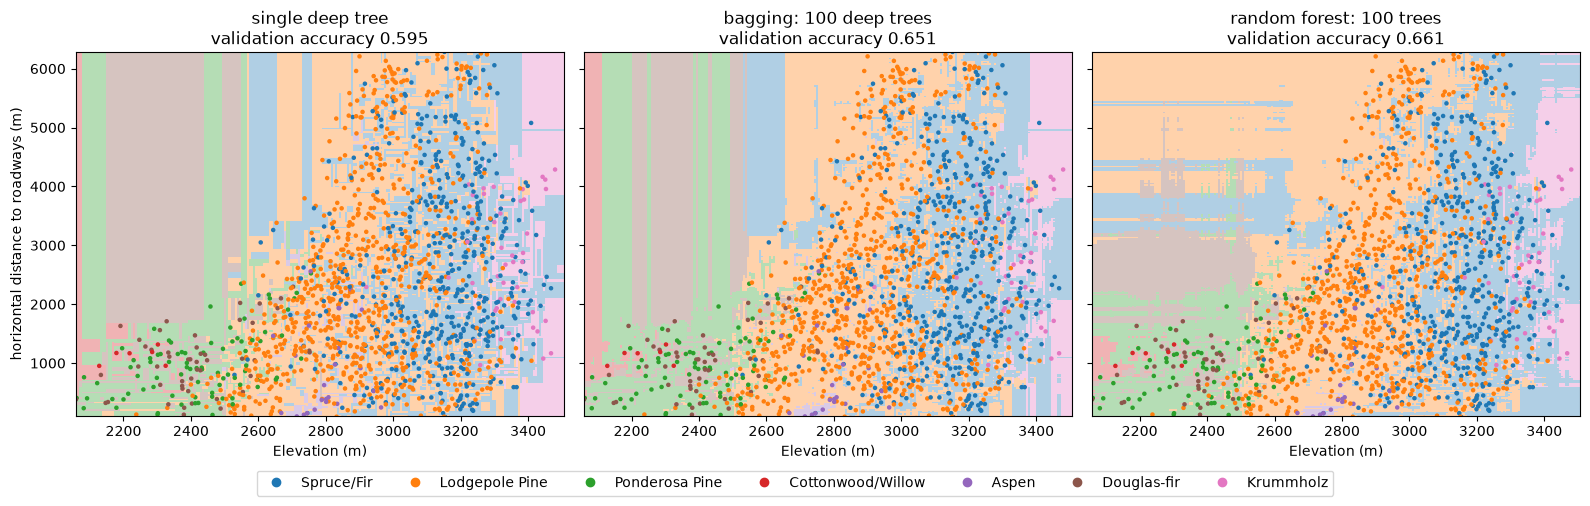

single deep tree           validation accuracy on 2 features: 0.595
bagging: 100 deep trees    validation accuracy on 2 features: 0.651
random forest: 100 trees   validation accuracy on 2 features: 0.661


In [4]:
two_features = ["Elevation", "Horizontal_Distance_To_Roadways"]
X2_tr, X2_val = X_cov_tr[two_features], X_cov_val[two_features]
boundary_models = {
    "single deep tree": DecisionTreeClassifier(random_state=SEED),
    "bagging: 100 deep trees": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, n_jobs=-1, random_state=SEED),
    "random forest: 100 trees": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
}

low = X2_tr.quantile(0.005)
high = X2_tr.quantile(0.995)
ee, rr = np.meshgrid(np.linspace(low.iloc[0], high.iloc[0], 250), np.linspace(low.iloc[1], high.iloc[1], 250))
grid = pd.DataFrame({two_features[0]: ee.ravel(), two_features[1]: rr.ravel()})
species_cmap = ListedColormap(plt.cm.tab10.colors[:7])
shown = X2_val.sample(1500, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
boundary_scores = {}
for ax, (name, model) in zip(axes, boundary_models.items()):
    model.fit(X2_tr, y_cov_tr)
    boundary_scores[name] = model.score(X2_val, y_cov_val)
    ax.pcolormesh(ee, rr, model.predict(grid).reshape(ee.shape), cmap=species_cmap, vmin=0.5, vmax=7.5,
                  alpha=0.35, shading="auto")
    ax.scatter(shown[two_features[0]], shown[two_features[1]], c=y_cov_val.loc[shown.index], cmap=species_cmap,
               vmin=0.5, vmax=7.5, s=5)
    ax.set(title=f"{name}\nvalidation accuracy {boundary_scores[name]:.3f}", xlabel="Elevation (m)",
           xlim=(low.iloc[0], high.iloc[0]), ylim=(low.iloc[1], high.iloc[1]))
axes[0].set_ylabel("horizontal distance to roadways (m)")
handles = [plt.Line2D([], [], marker="o", ls="", color=species_cmap(i), label=COVER_NAMES[i + 1]) for i in range(7)]
fig.legend(handles=handles, loc="lower center", ncol=7, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

for name, score in boundary_scores.items():
    print(f"{name:26s} validation accuracy on 2 features: {score:.3f}")

The single tree draws thousands of tiny, jagged islands: it memorized noise in the training plots. Bagging and the random forest average many such trees, so random islands cancel and the regions become smoother. With only 2 features, the forest's `max_features="sqrt"` means each split sees just **1** random feature — Section 4 explains why that helps.

One more practical property: scikit-learn's forests accept **missing values** directly.

In [5]:
X2_with_gaps = X2_tr.copy()
X2_with_gaps.iloc[::10, 0] = np.nan                       # remove 10% of the elevation values
gap_forest = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED).fit(X2_with_gaps, y_cov_tr)
print(f"trained with {int(X2_with_gaps.isna().sum().sum()):,} NaN values, no imputation | "
      f"validation accuracy {gap_forest.score(X2_val, y_cov_val):.3f}")
del gap_forest, val_predictions

trained with 1,500 NaN values, no imputation | validation accuracy 0.665


### ✍️ Your Turn

Using only the two features (`X2_tr`, `X2_val`), fit `RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1, random_state=SEED)` and store its **validation accuracy** in `rf2_acc`. The checker requires it to beat the single deep tree.

In [6]:
rf2_acc = None  # TODO: your code here
check("forest_beats_single_tree", None if rf2_acc is None else bool(rf2_acc > boundary_scores["single deep tree"]), True,
      hint="RandomForestClassifier(...).fit(X2_tr, y_cov_tr).score(X2_val, y_cov_val)")

⏳ forest_beats_single_tree: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rf2_acc = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, n_jobs=-1,
                                 random_state=SEED).fit(X2_tr, y_cov_tr).score(X2_val, y_cov_val)
print(f"forest {rf2_acc:.3f} vs single tree {boundary_scores['single deep tree']:.3f}")
check("forest_beats_single_tree", bool(rf2_acc > boundary_scores["single deep tree"]), True)
```

`min_samples_leaf=5` makes each tree a little smoother too; averaging 200 of them does the rest.
</details>

> 💡 **Interview angle:** "Why not just use one deep decision tree?" — a deep tree has low bias but **high variance**: small changes in the data give a very different tree. A forest keeps the low bias and averages the variance away. We measured it: two forests trained on different resamples disagree far less often than two trees.

## 2. The Math: Why Averaging Reduces Variance 🟡

Take one input $x$. Think of each tree's prediction $T_b(x)$ as a **random variable**: it depends on which training data and which random choices the tree got. Suppose every tree has
- the same variance $\sigma^2 = \operatorname{Var}(T_b(x))$, and
- the same pairwise correlation $\rho$ with every other tree.

The variance of the forest's average of $B$ trees is

$$\operatorname{Var}\Big(\frac{1}{B}\sum_{b=1}^{B} T_b(x)\Big) = \frac{1}{B^2}\Big[\underbrace{B\sigma^2}_{\text{each tree}} + \underbrace{B(B-1)\rho\sigma^2}_{\text{every pair}}\Big] = \rho\sigma^2 + \frac{1-\rho}{B}\,\sigma^2$$

Read it like this:
- **Independent trees** ($\rho = 0$): variance $\sigma^2/B$ → shrinks to zero with more trees.
- **Identical trees** ($\rho = 1$): variance $\sigma^2$ → averaging copies does nothing.
- **Real forests** ($0 < \rho < 1$): adding trees removes the second term, but the first term $\rho\sigma^2$ is a **floor**. The only way below the floor is to make the trees **less correlated**. That's why random forests sample features at every split.
- **Bias doesn't change:** $\mathbb{E}[\text{average}] = \mathbb{E}[T_b]$. So forests use **deep, low-bias** trees and let averaging fight the variance. (Boosting does the opposite, see [Gradient Boosting](10_Gradient_Boosting.ipynb).)
- **The catch:** hiding features makes each tree weaker, so $\sigma^2$ (and bias) go up. `max_features` trades lower $\rho$ against higher $\sigma^2$.

**Experiment (California housing, regression).** We draw 30 independent training sets of 2,000 districts. On each we train a 50-tree forest, and record every tree's prediction on the same 500 held-out districts. For each district we measure $\sigma^2$ (variance of one tree across training sets) and $\rho$ (average covariance between two trees of the same forest ÷ $\sigma^2$). Then we check the formula.

In [7]:
housing = fetch_california_housing(as_frame=True)
X_house, y_house = housing.data, housing.target
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X_house, y_house, test_size=0.2, random_state=SEED)
probe_X, probe_y = Xh_te.iloc[:500].to_numpy(), yh_te.iloc[:500].to_numpy()
N_REPEATS, N_TREES, TRAIN_SIZE = 30, 50, 2_000


def tree_prediction_cube(max_features):
    """cube[r, b, x] = prediction of tree b, from the forest trained on training set r, for probe district x."""
    cube = np.empty((N_REPEATS, N_TREES, len(probe_X)))
    for r in range(N_REPEATS):
        rows = np.random.default_rng(r).choice(len(Xh_tr), TRAIN_SIZE, replace=False)
        forest = RandomForestRegressor(n_estimators=N_TREES, max_features=max_features, n_jobs=-1, random_state=r)
        forest.fit(Xh_tr.iloc[rows].to_numpy(), yh_tr.iloc[rows].to_numpy())
        cube[r] = np.stack([tree.predict(probe_X) for tree in forest.estimators_])
    return cube


def variance_decomposition(cube):
    """Average one-tree variance σ² and between-tree correlation ρ over the probe districts."""
    n_repeats, n_trees, _ = cube.shape
    centered = cube - cube.mean(axis=(0, 1), keepdims=True)
    cov = np.einsum("rbx,rcx->bcx", centered, centered) / n_repeats      # tree-by-tree covariance per district
    variances = np.diagonal(cov, axis1=0, axis2=1)                       # shape (districts, trees)
    sigma2 = variances.mean()
    mean_covariance = (cov.sum(axis=(0, 1)) - variances.sum(axis=1)).mean() / (n_trees * (n_trees - 1))
    return sigma2, mean_covariance / sigma2


mf_settings = {"1.0 (plain bagging)": 1.0, "0.5": 0.5, "0.33 (≈ p/3)": 0.33, "1 feature": 1}
cubes, corr_rows = {}, []
start = time.perf_counter()
for label, max_features in mf_settings.items():
    cube = tree_prediction_cube(max_features)
    cubes[label] = cube
    sigma2, rho = variance_decomposition(cube)
    corr_rows.append({
        "max_features": label, "σ² one tree": sigma2, "ρ between trees": rho, "floor ρσ²": rho * sigma2,
        "formula B=50": rho * sigma2 + (1 - rho) * sigma2 / N_TREES,
        "measured Var(forest)": cube.mean(axis=1).var(axis=0).mean(),
        "MSE one tree": np.mean((cube[:, 0, :] - probe_y) ** 2),
        "MSE forest": np.mean((cube.mean(axis=1) - probe_y) ** 2),
    })
corr_table = pd.DataFrame(corr_rows).set_index("max_features")
print(f"{N_REPEATS * N_TREES * len(mf_settings):,} trees trained in {time.perf_counter() - start:.1f}s")
print(corr_table.round(4).to_string())

6,000 trees trained in 4.2s
                     σ² one tree  ρ between trees  floor ρσ²  formula B=50  measured Var(forest)  MSE one tree  MSE forest
max_features                                                                                                              
1.0 (plain bagging)       0.4007           0.0722     0.0289        0.0364                0.0364        0.6834      0.3200
0.5                       0.4267           0.0441     0.0188        0.0270                0.0270        0.6935      0.3076
0.33 (≈ p/3)              0.5069           0.0262     0.0133        0.0231                0.0231        0.7925      0.3090
1 feature                 0.6601           0.0175     0.0116        0.0245                0.0245        1.0056      0.3646


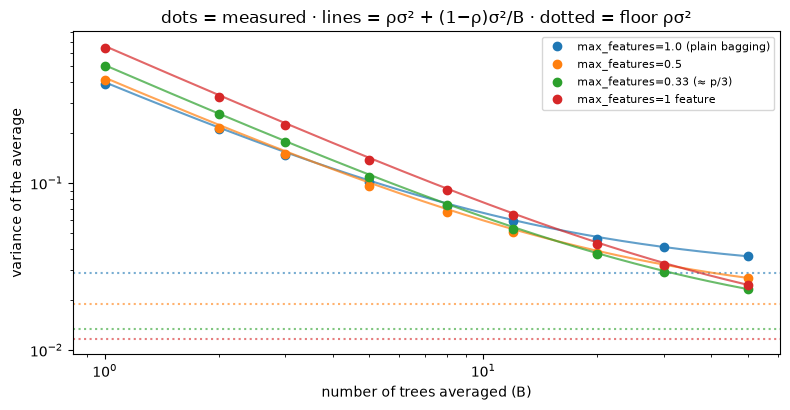

ρ falls from 0.072 (plain bagging) to 0.018 (1 feature per split), while one tree's σ² rises from 0.401 to 0.660.
Lowest measured forest variance: '0.33 (≈ p/3)' | lowest forest MSE on the probe districts: '0.5'.


In [8]:
tree_counts = np.array([1, 2, 3, 5, 8, 12, 20, 30, 50])
fig, ax = plt.subplots(figsize=(8, 4.2))
for (label, cube), color in zip(cubes.items(), plt.cm.tab10.colors):
    measured = [cube[:, :k, :].mean(axis=1).var(axis=0).mean() for k in tree_counts]
    s2, rho = corr_table.loc[label, ["σ² one tree", "ρ between trees"]]
    b_line = np.linspace(1, 50, 200)
    ax.plot(tree_counts, measured, "o", color=color, label=f"max_features={label}")
    ax.plot(b_line, rho * s2 + (1 - rho) * s2 / b_line, "-", color=color, alpha=0.7)
    ax.axhline(rho * s2, ls=":", color=color, alpha=0.6)
ax.set(xscale="log", yscale="log", xlabel="number of trees averaged (B)", ylabel="variance of the average",
       title="dots = measured · lines = ρσ² + (1−ρ)σ²/B · dotted = floor ρσ²")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ranked_rho = corr_table["ρ between trees"]
print(f"ρ falls from {ranked_rho.iloc[0]:.3f} (plain bagging) to {ranked_rho.iloc[-1]:.3f} (1 feature per split), "
      f"while one tree's σ² rises from {corr_table['σ² one tree'].iloc[0]:.3f} to {corr_table['σ² one tree'].iloc[-1]:.3f}.")
print(f"Lowest measured forest variance: '{corr_table['measured Var(forest)'].idxmin()}' | "
      f"lowest forest MSE on the probe districts: '{corr_table['MSE forest'].idxmin()}'.")
del cubes
gc.collect();

What the numbers say:
- The **formula matches the measurement**: the dots sit on the lines for every number of trees, not just at $B = 50$. (At $B=50$ they agree exactly, because we estimated $\sigma^2$ and $\rho$ from those same 50 trees. The smaller $B$ values are the real test.)
- Each curve **flattens at its floor** $\rho\sigma^2$. Past a few dozen trees, extra trees barely reduce variance.
- Showing fewer features per split **lowers ρ** but **raises σ²** (each tree is weaker). The forest's total error (MSE) balances variance against the extra bias, so the best `max_features` has to be found by validation (Section 4).

### ✍️ Your Turn

Trees with $\rho = 0.05$ and $\sigma^2 = 0.4$. How many trees $B$ do you need before the second term $\frac{(1-\rho)\sigma^2}{B}$ is at most **10% of the floor** $\rho\sigma^2$? Store the smallest integer in `trees_needed`.

In [9]:
rho_ex, sigma2_ex = 0.05, 0.4
trees_needed = None  # TODO: smallest integer B with (1 - rho) * sigma2 / B <= 0.1 * rho * sigma2
check("trees_needed", trees_needed, 190, hint="Solve for B: B >= (1 - rho) / (0.1 * rho), then round up with np.ceil.")

⏳ trees_needed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
rho_ex, sigma2_ex = 0.05, 0.4
trees_needed = int(np.ceil((1 - rho_ex) / (0.1 * rho_ex)))
check("trees_needed", trees_needed, 190)

rho_bag, s2_bag = corr_table.loc["1.0 (plain bagging)", ["ρ between trees", "σ² one tree"]]
print(f"with our measured plain-bagging ρ={rho_bag:.3f}: B ≥ {int(np.ceil((1 - rho_bag) / (0.1 * rho_bag)))}")
```

$\sigma^2$ cancels out: the answer depends only on $\rho$. The more correlated the trees, the *fewer* trees you need to reach the floor — but the floor itself is higher.
</details>

> 💡 **Interview angle:** "Why do random forests reduce variance?" — write $\operatorname{Var} = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$. More trees kill the second term; the floor $\rho\sigma^2$ is lowered by decorrelating the trees with bootstrap samples and random features per split. Averaging doesn't change bias, so we average deep, low-bias trees.

## 3. Bootstrap Sampling and BaggingClassifier 🟢

A **bootstrap sample** draws $n$ rows **with replacement** from $n$ rows. Some rows appear twice or more, some not at all.

The chance that one particular row is **never** drawn in $n$ draws is

$$\Big(1 - \frac{1}{n}\Big)^n \xrightarrow{\;n\to\infty\;} e^{-1} \approx 0.368$$

So each tree sees about **63.2%** of the unique rows. The other ≈36.8% are that tree's **out-of-bag (OOB)** rows — free test data for that tree (Section 5).

In [10]:
for n in [10, 100, 1_000, len(X_cov_tr)]:
    print(f"n = {n:>6,}: P(row out-of-bag) = {(1 - 1 / n) ** n:.4f} → unique share in the sample = {1 - (1 - 1 / n) ** n:.4f}")
print(f"limit      : e^-1 = {np.exp(-1):.4f}   → 1 - e^-1 = {1 - np.exp(-1):.4f}")

rf_boot = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
unique_share = np.array([len(np.unique(rows)) / len(X_cov_tr) for rows in rf_boot.estimators_samples_])
print(f"\nmeasured on {len(unique_share)} real bootstrap samples of {len(X_cov_tr):,} rows: "
      f"mean unique share {unique_share.mean():.4f} (min {unique_share.min():.4f}, max {unique_share.max():.4f})")
counts = np.bincount(rf_boot.estimators_samples_[0], minlength=len(X_cov_tr))
print("tree 0: how many rows were drawn 0, 1, 2, 3, 4+ times:",
      [int((counts == k).sum()) for k in range(4)] + [int((counts >= 4).sum())])
del rf_boot

n =     10: P(row out-of-bag) = 0.3487 → unique share in the sample = 0.6513
n =    100: P(row out-of-bag) = 0.3660 → unique share in the sample = 0.6340
n =  1,000: P(row out-of-bag) = 0.3677 → unique share in the sample = 0.6323
n = 15,000: P(row out-of-bag) = 0.3679 → unique share in the sample = 0.6321
limit      : e^-1 = 0.3679   → 1 - e^-1 = 0.6321



measured on 50 real bootstrap samples of 15,000 rows: mean unique share 0.6324 (min 0.6255, max 0.6390)
tree 0: how many rows were drawn 0, 1, 2, 3, 4+ times: [5536, 5495, 2766, 903, 300]


**Bagging works for any model**, not just trees. `BaggingClassifier(estimator=...)` trains copies of your model on bootstrap samples and averages their predicted probabilities. But it only helps **unstable** models, whose predictions change a lot with the data. Let's compare three learners on 4,000 Covertype rows with 3-fold cross-validation.

In [11]:
X_small, y_small = X_cov_tr.iloc[:4_000], y_cov_tr.iloc[:4_000]
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
learners = {
    "deep decision tree (unstable)": DecisionTreeClassifier(random_state=SEED),
    "1-nearest neighbour": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=1)),
    "logistic regression (stable)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5_000)),
}
bagging_rows = []
for name, learner in learners.items():
    start = time.perf_counter()
    single = cross_val_score(learner, X_small, y_small, cv=cv3).mean()
    bagged = cross_val_score(BaggingClassifier(learner, n_estimators=30, n_jobs=-1, random_state=SEED),
                             X_small, y_small, cv=cv3).mean()
    bagging_rows.append({"learner": name, "single CV acc": single, "bagged (30) CV acc": bagged,
                         "gain": bagged - single, "seconds": time.perf_counter() - start})
bagging_table = pd.DataFrame(bagging_rows).set_index("learner")
print(bagging_table.round(4).to_string())
print(f"\n→ Bagging helped '{bagging_table['gain'].idxmax()}' most (+{bagging_table['gain'].max():.3f}) and "
      f"'{bagging_table['gain'].idxmin()}' least ({bagging_table['gain'].min():+.3f}).")

                               single CV acc  bagged (30) CV acc    gain  seconds
learner                                                                          
deep decision tree (unstable)         0.6667              0.7485  0.0818   0.6250
1-nearest neighbour                   0.6957              0.6957  0.0000   1.2010
logistic regression (stable)          0.7225              0.7238  0.0013   0.9553

→ Bagging helped 'deep decision tree (unstable)' most (+0.082) and '1-nearest neighbour' least (+0.000).


A deep tree changes a lot when rows change, so averaging 30 of them is a big win. Logistic regression gives nearly the same model on every bootstrap sample ($\rho \approx 1$ in Section 2's language), so there is little variance to average away.

The 1-nearest-neighbour result is a classic (Breiman, 1996): a query's nearest training row lands in about 63% of bootstrap samples, i.e. in **most** bags, so the bagged vote almost always repeats plain 1-NN's answer. 1-NN is *stable* under bootstrap resampling, even though it looks "wiggly".

### ✍️ Your Turn

In a bootstrap sample of $n = 50$ rows, what is the probability that a given row appears **at least once**? Store it in `p_in_bootstrap`.

In [12]:
p_in_bootstrap = None  # TODO
check("p_in_bootstrap", p_in_bootstrap, 0.635830, hint="1 - P(never drawn) = 1 - (1 - 1/n) ** n")

⏳ p_in_bootstrap: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n = 50
p_in_bootstrap = 1 - (1 - 1 / n) ** n
check("p_in_bootstrap", p_in_bootstrap, 0.635830)
```

Already close to the limit $1 - e^{-1} \approx 0.632$ at $n = 50$.
</details>

> 💡 **Interview angle:** "What fraction of rows does each tree see?" — about 63.2% unique rows, because $P(\text{never drawn}) = (1-1/n)^n \to 1/e$. Add: bagging helps learners whose model changes a lot when the rows change (deep trees) and does little for stable ones (linear models, and even 1-NN, whose nearest neighbour is in most bootstrap samples).

## 4. Random Feature Subsampling With max_features 🟡

**The problem with plain bagging:** if one feature is very strong (here, `Elevation`), almost every bagged tree puts it at the root. The trees look alike, so $\rho$ is high and averaging helps less.

**The random forest fix (Breiman, 2001):** at **every split**, pick `max_features` features at random and choose the best split among only those. Sometimes the dominant feature isn't offered, so the tree must find other structure. The trees become more different.

| Setting | Features tried per split (p = number of features) | Default for |
|---|---|---|
| `"sqrt"` | $\max(1, \lfloor\sqrt{p}\rfloor)$ | `RandomForestClassifier`, `ExtraTreesClassifier` |
| `"log2"` | $\max(1, \lfloor\log_2 p\rfloor)$ | — |
| `1.0` or `None` | all $p$ (this is plain bagging of trees) | `RandomForestRegressor`, `ExtraTreesRegressor` |
| float `f` / int `k` | $\max(1, \lfloor f\cdot p\rfloor)$ / exactly $k$ | — |

⚠️ `BaggingClassifier(max_features=...)` is different: it picks one random feature subset **per tree** (the "random subspace" method), not per split.

First, direct evidence of decorrelation: which feature sits at the **root** of each tree?

In [13]:
root_rows = {}
for label, max_features in [("plain bagging (max_features=1.0)", 1.0), ("random forest (max_features='sqrt')", "sqrt")]:
    forest = RandomForestClassifier(n_estimators=100, max_features=max_features, n_jobs=-1, random_state=SEED)
    forest.fit(X_cov_tr, y_cov_tr)
    roots = Counter(X_cov_tr.columns[tree.tree_.feature[0]] for tree in forest.estimators_)
    root_rows[label] = roots
    print(f"{label}: {len(roots)} different root features across 100 trees | most common: {roots.most_common(3)}")
del forest

plain bagging (max_features=1.0): 1 different root features across 100 trees | most common: [('Elevation', 100)]
random forest (max_features='sqrt'): 17 different root features across 100 trees | most common: [('Soil_Type_21', 19), ('Elevation', 12), ('Soil_Type_9', 10)]


Now the trade-off in numbers: OOB accuracy (Section 5 explains it; think "free validation accuracy") for different `max_features`, 150 trees each.

              OOB accuracy  fit seconds
max_features                           
1                   0.8170       0.2747
2                   0.8201       0.2579
4                   0.8246       0.2871
7                   0.8273       0.2977
14                  0.8337       0.3637
27                  0.8384       0.4801
54                  0.8365       0.7631


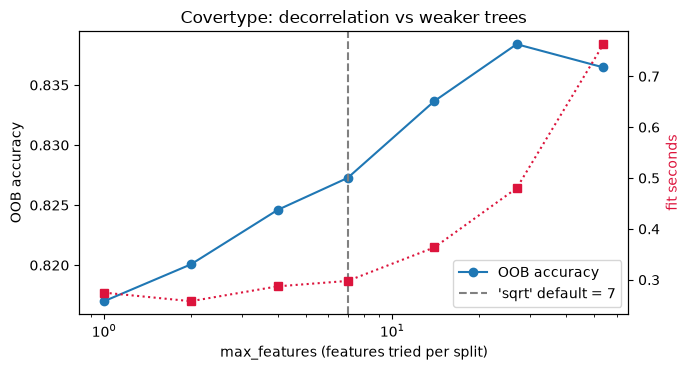

best max_features by OOB: 27 (0.8384) | 'sqrt' (7): 0.8273 | all 54 features (bagging): 0.8365 and 2.6× slower than 'sqrt'


In [14]:
n_features = X_cov_tr.shape[1]
mf_rows = []
for max_features in [1, 2, 4, int(np.sqrt(n_features)), 14, 27, n_features]:
    start = time.perf_counter()
    forest = RandomForestClassifier(n_estimators=150, max_features=max_features, oob_score=True, n_jobs=-1,
                                    random_state=SEED).fit(X_cov_tr, y_cov_tr)
    mf_rows.append({"max_features": max_features, "OOB accuracy": forest.oob_score_,
                    "fit seconds": time.perf_counter() - start})
    del forest
mf_table = pd.DataFrame(mf_rows).set_index("max_features")
print(mf_table.round(4).to_string())

fig, ax1 = plt.subplots(figsize=(7, 3.8))
ax1.plot(mf_table.index, mf_table["OOB accuracy"], "o-", label="OOB accuracy")
ax1.axvline(int(np.sqrt(n_features)), ls="--", color="gray", label=f"'sqrt' default = {int(np.sqrt(n_features))}")
ax1.set(xscale="log", xlabel="max_features (features tried per split)", ylabel="OOB accuracy",
        title="Covertype: decorrelation vs weaker trees")
ax2 = ax1.twinx()
ax2.plot(mf_table.index, mf_table["fit seconds"], "s:", color="crimson", label="fit seconds")
ax2.set_ylabel("fit seconds", color="crimson")
ax1.legend(loc="lower right")
plt.tight_layout()
plt.show()

best_mf = mf_table["OOB accuracy"].idxmax()
print(f"best max_features by OOB: {best_mf} ({mf_table.loc[best_mf, 'OOB accuracy']:.4f}) | 'sqrt' ({int(np.sqrt(n_features))}): "
      f"{mf_table.loc[int(np.sqrt(n_features)), 'OOB accuracy']:.4f} | all {n_features} features (bagging): "
      f"{mf_table.loc[n_features, 'OOB accuracy']:.4f} and {mf_table.loc[n_features, 'fit seconds'] / mf_table.loc[int(np.sqrt(n_features)), 'fit seconds']:.1f}× slower than 'sqrt'")

Three lessons from the printout:
- Very small `max_features` makes each tree too weak, and accuracy drops.
- Trying more features per split is **slower**, because each split evaluates more candidates.
- The default `"sqrt"` is only a starting point. On this dataset, a larger value beat it (see the best value above), so it pays to try a few values between $\sqrt{p}$ and $p$ with OOB or CV.

### ✍️ Your Turn

For a classification dataset with **54** features, how many features does each split consider for `"sqrt"`, `"log2"` and `1.0`? Fill in the dict.

In [15]:
features_per_split = None  # TODO: {"sqrt": ..., "log2": ..., "1.0": ...}
check("features_per_split", features_per_split, {"sqrt": 7, "log2": 5, "1.0": 54},
      hint="max(1, int(np.sqrt(54))), max(1, int(np.log2(54))), and all features for 1.0")

⏳ features_per_split: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p = 54
features_per_split = {"sqrt": max(1, int(np.sqrt(p))), "log2": max(1, int(np.log2(p))), "1.0": p}
check("features_per_split", features_per_split, {"sqrt": 7, "log2": 5, "1.0": 54})
```

scikit-learn rounds **down** ($\sqrt{54} \approx 7.35 \to 7$, $\log_2 54 \approx 5.75 \to 5$).
</details>

> 💡 **Interview angle:** "What's the difference between bagging and a random forest?" — a random forest is bagging of trees **plus random feature subsampling at every split**, which decorrelates the trees (lower $\rho$). Mention the defaults: $\sqrt{p}$ for classification, and that scikit-learn's `RandomForestRegressor` defaults to **all features** (plain bagging), while $p/3$ is the classic textbook choice.

## 5. Out-of-Bag Score vs Cross-Validation 🟡

Every row is out-of-bag for about 36.8% of the trees. The **OOB prediction** for a row uses only those trees:

1. For every tree, find the rows it did **not** train on.
2. Add that tree's predicted class probabilities to those rows' running totals.
3. Each row's OOB class is the class with the largest total (a *soft* vote). **OOB accuracy** compares these classes with the true labels.

It's like cross-validation that comes **for free**: one fit, no extra models. (We verify this exact definition in 🔧 Build It From Scratch.)

**Caveats:**
- Each row is predicted by only ≈37% of the trees, so with few trees the OOB score is a bit pessimistic.
- Anything fitted on **all** rows before the forest (target encoding, feature selection using the label) leaks into OOB rows and makes OOB optimistic. Cross-validate the whole pipeline instead.
- Grouped or time-ordered data: OOB rows are a random sample, so a patient's other visits or tomorrow's data may be in the bag. Use `GroupKFold` / `TimeSeriesSplit`.

Let's measure OOB against 5-fold cross-validation and against the held-out validation set.

In [16]:
start = time.perf_counter()
rf_oob = RandomForestClassifier(n_estimators=200, oob_score=True, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
oob_seconds = time.perf_counter() - start

start = time.perf_counter()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
                            X_cov_tr, y_cov_tr, cv=cv5)
cv_seconds = time.perf_counter() - start
val_accuracy = rf_oob.score(X_cov_val, y_cov_val)

oob_vs_cv = pd.DataFrame({
    "accuracy": [rf_oob.oob_score_, cv_scores.mean(), val_accuracy],
    "models trained": [1, 5, 1],
    "seconds": [oob_seconds, cv_seconds, np.nan],
}, index=["OOB (1 fit)", "5-fold CV", "held-out validation (5,000 rows)"])
print(oob_vs_cv.round(4).to_string())
print(f"\nCV fold spread: ±{cv_scores.std():.4f} | OOB − CV = {rf_oob.oob_score_ - cv_scores.mean():+.4f} | "
      f"OOB − validation = {rf_oob.oob_score_ - val_accuracy:+.4f}")
print(f"→ OOB cost {oob_seconds:.1f}s vs {cv_seconds:.1f}s for CV ({cv_seconds / oob_seconds:.1f}× more). "
      + ("The estimates agree within about 1 point." if abs(rf_oob.oob_score_ - cv_scores.mean()) < 0.01
         else "They differ by more than a point: inspect the caveats above."))
print("\nOOB class probabilities of the first 3 rows:\n", np.round(rf_oob.oob_decision_function_[:3], 3))

                                  accuracy  models trained  seconds
OOB (1 fit)                         0.8307               1   0.3815
5-fold CV                           0.8222               5   1.1838
held-out validation (5,000 rows)    0.8354               1      NaN

CV fold spread: ±0.0070 | OOB − CV = +0.0085 | OOB − validation = -0.0047
→ OOB cost 0.4s vs 1.2s for CV (3.1× more). The estimates agree within about 1 point.

OOB class probabilities of the first 3 rows:
 [[0.102 0.898 0.    0.    0.    0.    0.   ]
 [0.723 0.262 0.    0.    0.015 0.    0.   ]
 [0.29  0.435 0.    0.    0.    0.275 0.   ]]


The three estimates are close. CV models train on only 80% of the rows, and each OOB prediction uses only ≈37% of the trees, so both lean slightly pessimistic compared with a full 200-tree forest trained on all the rows.

### ✍️ Your Turn

`rf_oob.oob_decision_function_` holds the OOB class probabilities (columns in the order of `rf_oob.classes_`). Recompute the **OOB accuracy** from it and store it in `my_oob_accuracy`.

In [17]:
my_oob_accuracy = None  # TODO
check("my_oob_accuracy", my_oob_accuracy, rf_oob.oob_score_,
      hint="rf_oob.classes_[probabilities.argmax(axis=1)] gives each row's OOB class; compare with y_cov_tr.")

⏳ my_oob_accuracy: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
oob_classes = rf_oob.classes_[rf_oob.oob_decision_function_.argmax(axis=1)]
my_oob_accuracy = np.mean(oob_classes == y_cov_tr.to_numpy())
check("my_oob_accuracy", my_oob_accuracy, rf_oob.oob_score_)
```
</details>

> 💡 **Interview angle:** "What is out-of-bag error?" — each tree skips ≈36.8% of rows; predict every row with only the trees that didn't see it and score those predictions. It's a nearly free estimate of generalization error. Add the caveats: preprocessing fitted on all rows leaks into it, and it ignores group/time structure.

## 6. Extra Trees: Extremely Randomized Trees 🟢

**Extra trees** (Geurts, Ernst & Wehenkel, 2006) push randomness one step further:

| | Random forest | Extra trees |
|---|---|---|
| Rows per tree | bootstrap sample (`bootstrap=True`) | **all rows** by default (`bootstrap=False`) |
| Features per split | `max_features` random features | `max_features` random features |
| Threshold per feature | the **best** threshold (sorts the values) | **one random threshold** between the node's min and max, then keep the best of these random splits |
| Effect | | even less correlated trees, a bit more bias per tree, **faster splits**, usually **more nodes** |

Because extra trees don't bootstrap by default, they have **no OOB rows** unless you set `bootstrap=True`.

In [18]:
et_models = {
    "random forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
    "extra trees": ExtraTreesClassifier(n_estimators=100, n_jobs=-1, random_state=SEED),
    "extra trees + bootstrap": ExtraTreesClassifier(n_estimators=100, bootstrap=True, oob_score=True, n_jobs=-1,
                                                    random_state=SEED),
}
et_rows = []
for name, model in et_models.items():
    start = time.perf_counter()
    model.fit(X_cov_tr, y_cov_tr)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    accuracy = model.score(X_cov_val, y_cov_val)
    et_rows.append({"model": name, "val accuracy": accuracy, "fit s": fit_seconds,
                    "predict s": time.perf_counter() - start,
                    "nodes per tree": np.mean([tree.tree_.node_count for tree in model.estimators_]),
                    "depth": np.mean([tree.tree_.max_depth for tree in model.estimators_]),
                    "memory MB": forest_mb(model),
                    "OOB": getattr(model, "oob_score_", np.nan)})
    et_models[name] = None                                  # free memory as we go
et_table = pd.DataFrame(et_rows).set_index("model")
print(et_table.round(3).to_string())

rf_row, et_row = et_table.loc["random forest"], et_table.loc["extra trees"]
print(f"\n→ extra trees: {et_row['val accuracy'] - rf_row['val accuracy']:+.4f} accuracy vs the random forest, "
      f"{rf_row['fit s'] / et_row['fit s']:.1f}× faster to fit, {et_row['nodes per tree'] / rf_row['nodes per tree']:.1f}× more nodes per tree.")
gc.collect();

                         val accuracy  fit s  predict s  nodes per tree  depth  memory MB    OOB
model                                                                                           
random forest                   0.835  0.120      0.017         5584.94  37.13     67.019    NaN
extra trees                     0.841  0.091      0.017        14802.42  49.21    177.629    NaN
extra trees + bootstrap         0.827  0.181      0.013         9896.26  47.22    118.755  0.826

→ extra trees: +0.0060 accuracy vs the random forest, 1.3× faster to fit, 2.7× more nodes per tree.


Random thresholds are cheap to compute, so extra trees **train faster**. But random splits separate the classes less cleanly, so each tree needs **more nodes** to become pure: bigger models and slower predictions. Accuracy is often close to a random forest's; which one wins depends on the dataset, so compare both with the same folds (Section 12 and the 🚀 Mini Project).

> 💡 **Interview angle:** "Random forest vs extra trees?" — extra trees choose split thresholds at random and (by default) use the full dataset instead of bootstrap samples. That lowers variance further at a small cost in bias and makes training faster; the trees usually end up larger.

## 7. Hyperparameters: Number of Trees, Depth and Leaf Size 🟡

| Hyperparameter | What it controls | Effect | Sensible start |
|---|---|---|---|
| `n_estimators` | number of trees | lowers variance until the floor $\rho\sigma^2$; **never overfits by itself**; cost grows linearly | 200–500 |
| `max_features` | features tried per split (Section 4) | lower → less correlated but weaker trees | `"sqrt"` (clf), 0.33–1.0 (reg) |
| `max_depth` | maximum depth of each tree | `None` = fully grown, low bias; a limit shrinks the model | `None`, or 15–30 to cap size |
| `min_samples_leaf` | minimum (weighted) rows per leaf | smoother trees, **much smaller models**, better probabilities on noisy data | 1–10 |
| `max_samples` | rows drawn per bootstrap sample | smaller → more diverse, faster trees | `None` (= n), try 0.5 on big data |
| `class_weight` | per-class weights (Section 8) | shifts attention to rare classes | `None` or `"balanced_subsample"` |

### 7a. `n_estimators`: diminishing returns

`warm_start=True` lets us **add** trees to an existing forest instead of retraining from zero, and read the OOB accuracy after each step.

       OOB accuracy  cumulative fit s  memory MB
trees                                           
30           0.8031            0.0799    20.1060
50           0.8192            0.1643    33.5071
100          0.8249            0.3076    67.0193
200          0.8307            0.5915   133.9879
300          0.8310            0.9587   201.0262
400          0.8316            1.3791   268.0078


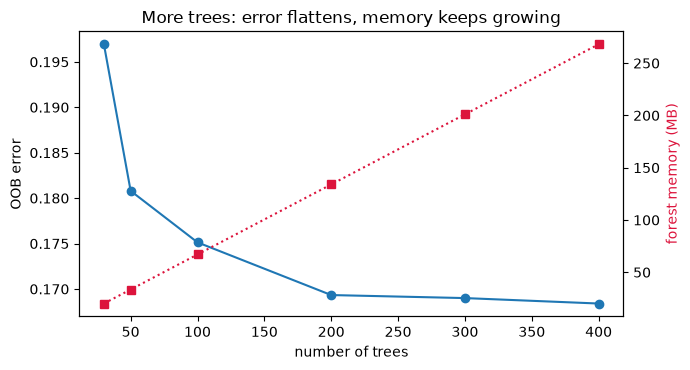

30 → 100 trees: +0.0218 OOB accuracy | 100 → 400 trees: +0.0067 for 4.0× the memory


In [19]:
growing_forest = RandomForestClassifier(n_estimators=30, warm_start=True, oob_score=True, n_jobs=-1, random_state=SEED)
curve_rows, cumulative_seconds = [], 0.0
for n_trees in [30, 50, 100, 200, 300, 400]:
    growing_forest.set_params(n_estimators=n_trees)
    start = time.perf_counter()
    growing_forest.fit(X_cov_tr, y_cov_tr)                 # only the new trees are trained
    cumulative_seconds += time.perf_counter() - start
    curve_rows.append({"trees": n_trees, "OOB accuracy": growing_forest.oob_score_,
                       "cumulative fit s": cumulative_seconds, "memory MB": forest_mb(growing_forest)})
oob_curve = pd.DataFrame(curve_rows).set_index("trees")
print(oob_curve.round(4).to_string())

fig, ax1 = plt.subplots(figsize=(7, 3.8))
ax1.plot(oob_curve.index, 1 - oob_curve["OOB accuracy"], "o-")
ax1.set(xlabel="number of trees", ylabel="OOB error", title="More trees: error flattens, memory keeps growing")
ax2 = ax1.twinx()
ax2.plot(oob_curve.index, oob_curve["memory MB"], "s:", color="crimson")
ax2.set_ylabel("forest memory (MB)", color="crimson")
plt.tight_layout()
plt.show()

gain_early = oob_curve.loc[100, "OOB accuracy"] - oob_curve.loc[30, "OOB accuracy"]
gain_late = oob_curve.loc[400, "OOB accuracy"] - oob_curve.loc[100, "OOB accuracy"]
print(f"30 → 100 trees: {gain_early:+.4f} OOB accuracy | 100 → 400 trees: {gain_late:+.4f} for "
      f"{oob_curve.loc[400, 'memory MB'] / oob_curve.loc[100, 'memory MB']:.1f}× the memory")
del growing_forest
gc.collect();

The first few dozen trees matter most; after that, accuracy creeps up while memory and prediction time grow linearly. The error never turns back up: **adding trees does not overfit** a random forest.

### 7b. `max_depth` and `min_samples_leaf`: accuracy vs model size

A 4 × 3 grid, 100 trees each, scored on the validation set. (For a real model you'd use cross-validation; here we just want to see the trends.)

validation accuracy:
 min_samples_leaf      1       5       20
max_depth                               
8                 0.7228  0.7204  0.7100
16                0.7944  0.7730  0.7396
32                0.8348  0.7896  0.7464
None              0.8352  0.7902  0.7464 

training accuracy:
 min_samples_leaf      1       5       20
max_depth                               
8                 0.7431  0.7333  0.7190
16                0.8991  0.8283  0.7613
32                0.9999  0.8775  0.7725
None              1.0000  0.8796  0.7725 

memory (MB):
 min_samples_leaf    1     5    20
max_depth                        
8                  3.3   2.6  1.6
16                26.9  13.7  5.2
32                65.8  23.0  6.4
None              67.0  23.1  6.4


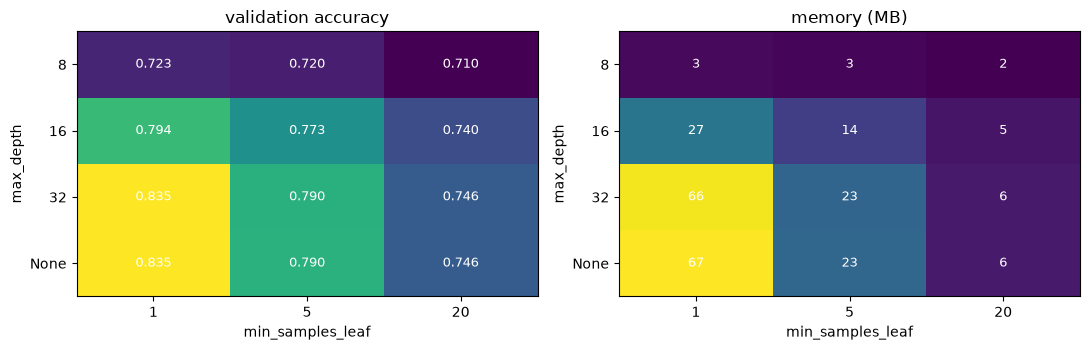

best: max_depth=None, min_samples_leaf=1 → val 0.8352, 67 MB
smallest within 1 point: max_depth=32, min_samples_leaf=1 → val 0.8348, 66 MB (1.0× smaller)


In [20]:
depth_order = ["8", "16", "32", "None"]
size_rows = []
for max_depth in [8, 16, 32, None]:
    for min_samples_leaf in [1, 5, 20]:
        forest = RandomForestClassifier(n_estimators=100, max_depth=max_depth, min_samples_leaf=min_samples_leaf,
                                        n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
        size_rows.append({"max_depth": str(max_depth), "min_samples_leaf": min_samples_leaf,
                          "train accuracy": forest.score(X_cov_tr, y_cov_tr),
                          "val accuracy": forest.score(X_cov_val, y_cov_val), "memory MB": forest_mb(forest)})
        del forest
size_table = pd.DataFrame(size_rows)
val_grid = size_table.pivot(index="max_depth", columns="min_samples_leaf", values="val accuracy").reindex(depth_order)
mem_grid = size_table.pivot(index="max_depth", columns="min_samples_leaf", values="memory MB").reindex(depth_order)
train_grid = size_table.pivot(index="max_depth", columns="min_samples_leaf", values="train accuracy").reindex(depth_order)
print("validation accuracy:\n", val_grid.round(4), "\n\ntraining accuracy:\n", train_grid.round(4),
      "\n\nmemory (MB):\n", mem_grid.round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, grid_values, title, fmt in [(axes[0], val_grid, "validation accuracy", "{:.3f}"), (axes[1], mem_grid, "memory (MB)", "{:.0f}")]:
    ax.imshow(grid_values.to_numpy(), cmap="viridis", aspect="auto")
    ax.set(xticks=range(3), xticklabels=grid_values.columns, yticks=range(4), yticklabels=grid_values.index,
           xlabel="min_samples_leaf", ylabel="max_depth", title=title)
    for i in range(grid_values.shape[0]):
        for j in range(grid_values.shape[1]):
            ax.text(j, i, fmt.format(grid_values.iloc[i, j]), ha="center", va="center", color="white", fontsize=9)
plt.tight_layout()
plt.show()

best = size_table.loc[size_table["val accuracy"].idxmax()]
near_best = size_table[size_table["val accuracy"] >= best["val accuracy"] - 0.01]
smallest = near_best.loc[near_best["memory MB"].idxmin()]
print(f"best: max_depth={best['max_depth']}, min_samples_leaf={best['min_samples_leaf']} → val {best['val accuracy']:.4f}, "
      f"{best['memory MB']:.0f} MB")
print(f"smallest within 1 point: max_depth={smallest['max_depth']}, min_samples_leaf={smallest['min_samples_leaf']} → "
      f"val {smallest['val accuracy']:.4f}, {smallest['memory MB']:.0f} MB ({best['memory MB'] / smallest['memory MB']:.1f}× smaller)")

- **Fully grown trees** (`max_depth=None`, `min_samples_leaf=1`) reach ~100% training accuracy. That is normal for a forest, and the validation score is still good, because averaging handles the variance.
- **Shallow trees** (`max_depth=8`) underfit: bias is something averaging cannot fix.
- `min_samples_leaf` and `max_depth` are your main **model-size** knobs. On Covertype they cost real accuracy: the species boundaries need very fine-grained splits, so fully grown trees win. On noisier data, larger leaves can be nearly free or even better; in the 🚀 Mini Project, cross-validation picks `min_samples_leaf=10` for Adult income.

> 💡 **Interview angle:** "Can a random forest overfit?" — adding **trees** doesn't overfit: test error flattens. But each tree is fully grown and fits noise, so on very noisy data a forest can still overfit. You regularize the **trees** with `min_samples_leaf`, `max_depth` or `max_features`, not the number of trees.

## 8. Class Imbalance: Balanced Subsamples and Balanced Forests 🟡

New task: is this patch of forest **Aspen**? Only about 1.6% of plots are. With so few positives, a forest can score 98% accuracy by never predicting Aspen, so we look at **PR-AUC** (average precision), **recall** (share of Aspen plots found), **precision** (share of flagged plots that really are Aspen) and **balanced accuracy**.

Options for a random forest:
- `class_weight="balanced"`: weight each class by $\frac{n}{K \cdot n_c}$, computed once on the whole training set.
- `class_weight="balanced_subsample"`: the same formula, **recomputed on each tree's bootstrap sample**.
- `BalancedRandomForestClassifier` (imbalanced-learn; Chen, Liaw & Breiman, 2004): each tree trains on a bootstrap sample that is **randomly undersampled** so both classes are equally common.
- **Tune the decision threshold** instead of 0.5. A forest gives OOB probabilities for every training row, so we can pick the threshold without touching the validation set.

⚠️ A subtle point we'll see in the numbers: in **fully grown** trees every leaf is pure, so class weights change the chosen splits a little but leaf probabilities barely change. Weights bite harder when leaves hold several rows (`min_samples_leaf > 1`).

In [21]:
X_asp, _, species_asp, _ = train_test_split(X_cover_all, y_cover_all, train_size=40_000, stratify=y_cover_all,
                                            random_state=SEED + 1)
y_asp = (species_asp == 5).astype(int)                                  # 5 = Aspen
X_as_tr, X_as_val, y_as_tr, y_as_val = train_test_split(X_asp, y_asp, test_size=0.3, stratify=y_asp, random_state=SEED)
print(f"train {len(X_as_tr):,} rows with {int(y_as_tr.sum())} Aspen ({y_as_tr.mean():.2%}) | "
      f"validation {len(X_as_val):,} rows with {int(y_as_val.sum())} Aspen")


def imbalance_metrics(y_true, proba, threshold=0.5):
    predicted = (proba >= threshold).astype(int)
    return {"PR-AUC": average_precision_score(y_true, proba), "ROC-AUC": roc_auc_score(y_true, proba),
            "precision": precision_score(y_true, predicted, zero_division=0), "recall": recall_score(y_true, predicted),
            "F1": f1_score(y_true, predicted, zero_division=0),
            "balanced acc": balanced_accuracy_score(y_true, predicted), "flagged %": 100 * predicted.mean()}


imbalance_models = {
    "RF default": RandomForestClassifier(n_estimators=200, oob_score=True, n_jobs=-1, random_state=SEED),
    "RF balanced_subsample": RandomForestClassifier(n_estimators=200, class_weight="balanced_subsample",
                                                    n_jobs=-1, random_state=SEED),
    "RF balanced_subsample + min_samples_leaf=10": RandomForestClassifier(
        n_estimators=200, class_weight="balanced_subsample", min_samples_leaf=10, n_jobs=-1, random_state=SEED),
    "BalancedRandomForest (imblearn)": BalancedRandomForestClassifier(
        n_estimators=200, sampling_strategy="all", replacement=True, bootstrap=False, n_jobs=-1, random_state=SEED),
}
imbalance_rows = {}
for name, model in imbalance_models.items():
    start = time.perf_counter()
    model.fit(X_as_tr, y_as_tr)
    proba = model.predict_proba(X_as_val)[:, 1]
    imbalance_rows[name] = {**imbalance_metrics(y_as_val, proba), "fit s": time.perf_counter() - start}

# Threshold tuning on the default forest, using OOB probabilities of the TRAINING rows (validation stays untouched)
rf_default = imbalance_models["RF default"]
oob_proba = rf_default.oob_decision_function_[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
oob_f1 = [f1_score(y_as_tr, (oob_proba >= t).astype(int), zero_division=0) for t in thresholds]
oob_threshold = float(thresholds[int(np.argmax(oob_f1))])
imbalance_rows[f"RF default, OOB-tuned threshold {oob_threshold:.2f}"] = {
    **imbalance_metrics(y_as_val, rf_default.predict_proba(X_as_val)[:, 1], threshold=oob_threshold),
    "fit s": imbalance_rows["RF default"]["fit s"]}

imbalance_table = pd.DataFrame(imbalance_rows).T
print(imbalance_table.round(3).to_string())
print(f"\nhighest PR-AUC: {imbalance_table['PR-AUC'].idxmax()} | highest recall: {imbalance_table['recall'].idxmax()} "
      f"| highest F1: {imbalance_table['F1'].idxmax()}")
default_recall = imbalance_table.loc["RF default", "recall"]
brf = imbalance_table.loc["BalancedRandomForest (imblearn)"]
print(f"BalancedRandomForest: recall {default_recall:.2f} → {brf['recall']:.2f}, "
      f"precision {imbalance_table.loc['RF default', 'precision']:.2f} → {brf['precision']:.2f}, "
      f"flags {brf['flagged %']:.1f}% of plots.")
del imbalance_models, rf_default
gc.collect();

train 28,000 rows with 458 Aspen (1.64%) | validation 12,000 rows with 196 Aspen


                                             PR-AUC  ROC-AUC  precision  recall     F1  balanced acc  flagged %  fit s
RF default                                    0.694    0.976      0.931   0.276  0.425         0.638      0.483  0.425
RF balanced_subsample                         0.686    0.978      0.931   0.276  0.425         0.638      0.483  0.340
RF balanced_subsample + min_samples_leaf=10   0.589    0.975      0.408   0.663  0.505         0.824      2.658  0.345
BalancedRandomForest (imblearn)               0.595    0.975      0.152   0.908  0.261         0.912      9.733  0.357
RF default, OOB-tuned threshold 0.20          0.694    0.976      0.670   0.663  0.667         0.829      1.617  0.425

highest PR-AUC: RF default | highest recall: BalancedRandomForest (imblearn) | highest F1: RF default, OOB-tuned threshold 0.20
BalancedRandomForest: recall 0.28 → 0.91, precision 0.93 → 0.15, flags 9.7% of plots.


How to read this:
- The **ranking** metrics (PR-AUC, ROC-AUC) move much less than recall and precision. Most methods reorder the same scores; they mainly move **where the 0.5 cut-off lands**.
- `BalancedRandomForestClassifier` finds many more Aspen plots (high recall) but flags many false alarms (low precision). That is the right trade when missing a positive is expensive (fraud, disease screening).
- Simply **choosing a better threshold** on OOB probabilities is often competitive and keeps one model. Decide with a cost for each kind of error, not with accuracy.

### ✍️ Your Turn

Compute the `"balanced"` class weights $\frac{n}{K\cdot n_c}$ **by hand** for the labels below (one weight per row), and store them in `balanced_weights`. The checker compares with scikit-learn's `compute_sample_weight`.

In [22]:
labels_ex = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])
balanced_weights = None  # TODO: array of 10 weights
check("balanced_weights", balanced_weights, compute_sample_weight("balanced", labels_ex),
      hint="n / (K * count of that row's class): n=10, K=2, counts 8 and 2.")

⏳ balanced_weights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
labels_ex = np.array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1])
class_counts = np.bincount(labels_ex)
balanced_weights = len(labels_ex) / (len(class_counts) * class_counts[labels_ex])
check("balanced_weights", balanced_weights, compute_sample_weight("balanced", labels_ex))
print(balanced_weights)
```

Each class ends up with the same **total** weight: 8 × 0.625 = 2 × 2.5 = 5. With `"balanced_subsample"` the counts come from each tree's bootstrap sample instead.
</details>

> 💡 **Interview angle:** "How do you handle a 1:60 imbalance with a random forest?" — stratified splits; PR-AUC / recall at a fixed precision instead of accuracy; then `class_weight="balanced_subsample"` (with `min_samples_leaf > 1` so weights matter), a **balanced random forest** that undersamples per tree, or just a tuned threshold on OOB or validation probabilities. Pick by the business cost of false negatives vs false positives.

## 9. Feature Importance Pitfalls: MDI vs Permutation 🔴

`forest.feature_importances_` is **Mean Decrease in Impurity (MDI)**. For every split on feature $j$ in every tree, it adds up the weighted drop in impurity

$$\text{MDI}_j = \frac{1}{B}\sum_{b}\ \sum_{\text{splits on } j} \frac{n_{\text{node}}}{n}\Big(\text{Gini}_{\text{node}} - \frac{n_L}{n_{\text{node}}}\text{Gini}_L - \frac{n_R}{n_{\text{node}}}\text{Gini}_R\Big)$$

and normalizes the result to sum to 1. Two problems:
1. It's computed on the **training data**, which fully grown trees memorize.
2. A feature with **many unique values** (a continuous number, an ID) offers thousands of candidate thresholds, so deep in a tree it often finds a split that looks useful by pure chance. MDI is **biased towards high-cardinality features** (Strobl et al., 2007).

**Permutation importance** shuffles one column in **held-out** data and measures how much the score drops. If the model really uses the feature, the score falls; if not, nothing happens. It's slower, and correlated features share credit (covered in [Scikit-Learn](02_Scikit_Learn.ipynb), Section 12). Here we focus on the cardinality bias.

**Experiment:** the Adult census data plus two columns of **pure noise**: `random_num` (continuous, ~all values unique) and `random_cat` (3 random categories). A trustworthy method must rank both near the bottom.

In [23]:
adult = fetch_openml("adult", version=2, as_frame=True)
X_adult = adult.data
y_adult = (adult.target == ">50K").astype(int)
X_ad_tr, X_ad_te, y_ad_tr, y_ad_te = train_test_split(X_adult, y_adult, test_size=0.2, stratify=y_adult, random_state=SEED)
# The test split (X_ad_te) is used exactly once, at the end of the 🚀 Mini Project.
X_imp_tr, X_imp_val, y_imp_tr, y_imp_val = train_test_split(X_ad_tr, y_ad_tr, test_size=0.25, stratify=y_ad_tr,
                                                            random_state=SEED)


def make_tree_preprocessor():
    """Ordinal-encode the categorical columns (fine for trees), pass numbers through, keep column names."""
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-2)
    return make_column_transformer((encoder, make_column_selector(dtype_include="category")), remainder="passthrough",
                                   verbose_feature_names_out=False).set_output(transform="pandas")


def add_noise_columns(X, seed):
    noise_rng = np.random.default_rng(seed)
    return X.assign(random_num=noise_rng.normal(size=len(X)), random_cat=noise_rng.integers(0, 3, size=len(X)))


Xn_tr, Xn_val = add_noise_columns(X_imp_tr, 1), add_noise_columns(X_imp_val, 2)
print(f"train {len(Xn_tr):,} · validation {len(Xn_val):,} rows | positive rate {y_imp_tr.mean():.1%}")
print("number of unique values per column:")
print(Xn_tr.nunique().sort_values(ascending=False).to_string())

train 29,304 · validation 9,769 rows | positive rate 23.9%
number of unique values per column:
random_num        29304
fnlwgt            20141
capital-gain        121
hours-per-week       95
capital-loss         94
age                  72
native-country       41
education            16
education-num        16
occupation           14
workclass             8
marital-status        7
relationship          6
race                  5
random_cat            3
sex                   2


In [24]:
start = time.perf_counter()
deep_forest = make_pipeline(make_tree_preprocessor(),
                            RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)).fit(Xn_tr, y_imp_tr)
mdi = pd.Series(deep_forest[-1].feature_importances_, index=deep_forest[:-1].get_feature_names_out())

val_rows, train_rows = Xn_val.iloc[:4_000], Xn_tr.iloc[:4_000]
perm_val = permutation_importance(deep_forest, val_rows, y_imp_val.iloc[:4_000], scoring="roc_auc", n_repeats=5,
                                  random_state=SEED)
perm_train = permutation_importance(deep_forest, train_rows, y_imp_tr.iloc[:4_000], scoring="roc_auc", n_repeats=3,
                                    random_state=SEED)
importance = pd.DataFrame({
    "MDI (train)": mdi,
    "permutation (train)": pd.Series(perm_train.importances_mean, index=train_rows.columns),
    "permutation (validation)": pd.Series(perm_val.importances_mean, index=val_rows.columns),
    "perm. val std": pd.Series(perm_val.importances_std, index=val_rows.columns),
})
importance_ranks = importance.drop(columns="perm. val std").rank(ascending=False).astype(int)
print(f"computed in {time.perf_counter() - start:.1f}s | validation ROC-AUC {roc_auc_score(y_imp_val, deep_forest.predict_proba(Xn_val)[:, 1]):.4f}")
print(importance.sort_values("MDI (train)", ascending=False).round(4).to_string())
print(f"\nrank (1 = most important of {len(importance)}) of the noise columns:")
print(importance_ranks.loc[["random_num", "random_cat"]].to_string())

computed in 5.0s | validation ROC-AUC 0.9138
                MDI (train)  permutation (train)  permutation (validation)  perm. val std
age                  0.1138               0.0435                    0.0235         0.0040
fnlwgt               0.1137               0.0131                    0.0004         0.0013
random_num           0.1110               0.0085                   -0.0007         0.0009
relationship         0.1101               0.0228                    0.0386         0.0023
capital-gain         0.1076               0.0349                    0.0477         0.0015
education-num        0.0934               0.0410                    0.0270         0.0018
marital-status       0.0680               0.0041                    0.0247         0.0018
hours-per-week       0.0680               0.0269                    0.0136         0.0011
occupation           0.0554               0.0151                    0.0073         0.0020
capital-loss         0.0346               0.0055       

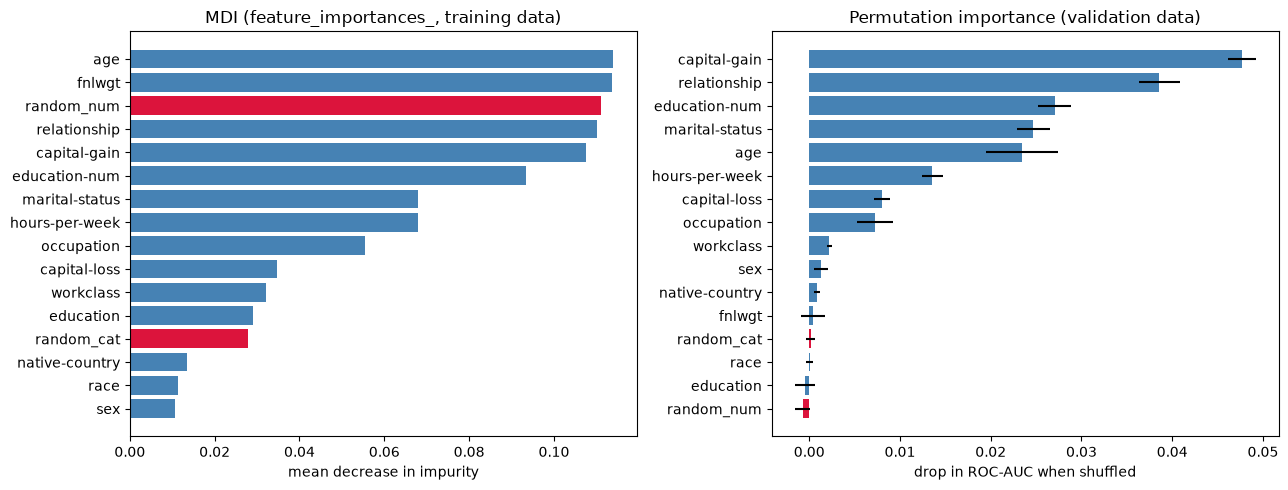

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
order = importance["MDI (train)"].sort_values().index
colors = ["crimson" if name.startswith("random_") else "steelblue" for name in order]
axes[0].barh(order, importance.loc[order, "MDI (train)"], color=colors)
axes[0].set(title="MDI (feature_importances_, training data)", xlabel="mean decrease in impurity")
order_p = importance["permutation (validation)"].sort_values().index
axes[1].barh(order_p, importance.loc[order_p, "permutation (validation)"],
             xerr=importance.loc[order_p, "perm. val std"],
             color=["crimson" if name.startswith("random_") else "steelblue" for name in order_p])
axes[1].set(title="Permutation importance (validation data)", xlabel="drop in ROC-AUC when shuffled")
plt.tight_layout()
plt.show()

Now the fix on the model side: larger leaves stop trees from chasing noise deep down, so MDI's bias shrinks (though it doesn't vanish).

In [26]:
leafy_forest = make_pipeline(make_tree_preprocessor(), RandomForestClassifier(
    n_estimators=200, min_samples_leaf=20, n_jobs=-1, random_state=SEED)).fit(Xn_tr, y_imp_tr)
leafy_mdi = pd.Series(leafy_forest[-1].feature_importances_, index=leafy_forest[:-1].get_feature_names_out())
for label, series in [("min_samples_leaf=1 ", mdi), ("min_samples_leaf=20", leafy_mdi)]:
    ranks = series.rank(ascending=False).astype(int)
    print(f"{label}: random_num MDI rank {ranks['random_num']:>2} (share {series['random_num']:.3f}) | "
          f"random_cat rank {ranks['random_cat']:>2} (share {series['random_cat']:.3f})")
r_mdi, r_perm = importance_ranks.loc["random_num", "MDI (train)"], importance_ranks.loc["random_num", "permutation (validation)"]
print(f"\n→ Pure noise 'random_num' ranked #{r_mdi} by MDI but #{r_perm} by validation permutation importance "
      f"(mean drop {importance.loc['random_num', 'permutation (validation)']:+.4f} AUC ≈ 0).")
del leafy_forest
gc.collect();

min_samples_leaf=1 : random_num MDI rank  3 (share 0.111) | random_cat rank 13 (share 0.028)
min_samples_leaf=20: random_num MDI rank 11 (share 0.022) | random_cat rank 14 (share 0.005)

→ Pure noise 'random_num' ranked #3 by MDI but #16 by validation permutation importance (mean drop -0.0007 AUC ≈ 0).


What happened:
- **MDI** gives the continuous noise column a large share, above several real features: its ~all-unique values let deep trees split on it again and again. The 3-level noise column gets little, because it offers only a couple of thresholds.
- **Permutation importance on training data** also credits the noise a bit: the forest memorized it on those rows.
- **Permutation importance on validation data** puts both noise columns at ≈0, with error bars crossing zero. That's the honest view of what the model uses to **generalize**.

### ✍️ Your Turn

What share of the total MDI (`mdi` sums to 1) went to the two noise columns together? Store it in `noise_mdi_share`.

In [27]:
noise_mdi_share = None  # TODO
check("noise_mdi_share", noise_mdi_share, float(mdi["random_num"] + mdi["random_cat"]),
      hint="Select both entries of the `mdi` Series and sum them.")

⏳ noise_mdi_share: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
noise_mdi_share = mdi[["random_num", "random_cat"]].sum()
print(f"{noise_mdi_share:.1%} of all impurity reduction was spent on pure noise")
check("noise_mdi_share", noise_mdi_share, float(mdi["random_num"] + mdi["random_cat"]))
```
</details>

> 💡 **Interview angle:** "Can you trust `feature_importances_` from a random forest?" — it's MDI, computed on training data and **biased towards high-cardinality features** (a random continuous column can rank high). Use **permutation importance on held-out data** (or SHAP), sanity-check with a random column, and remember correlated features split credit.

## 10. Speed, Parallelism, Model Size and Memory 🟡

Trees are independent, so `n_jobs` trains them on several cores at once (scikit-learn uses threads; the tree-building code releases Python's GIL). Prediction is parallel too. But a forest stores **every node of every tree**, so fully grown forests get big.

In [28]:
speed_rows = []
for n_jobs in [1, 2, 4, -1]:
    forest = RandomForestClassifier(n_estimators=100, n_jobs=n_jobs, random_state=SEED)
    start = time.perf_counter()
    forest.fit(X_cov_tr, y_cov_tr)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    forest.predict(X_cov_val)
    speed_rows.append({"n_jobs": str(n_jobs), "fit s": fit_seconds, "predict 5,000 rows s": time.perf_counter() - start})
speed_table = pd.DataFrame(speed_rows).set_index("n_jobs")
speed_table["fit speed-up"] = speed_table.loc["1", "fit s"] / speed_table["fit s"]
print(f"{N_CPUS} CPU cores")
print(speed_table.round(3).to_string())


def median_latency_ms(model, X_one, repeats=40):
    model.predict(X_one)                                   # warm-up
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        model.predict(X_one)
        timings.append(time.perf_counter() - start)
    return 1000 * float(np.median(timings))


one_row = X_cov_val.iloc[[0]]
latency_parallel = median_latency_ms(forest, one_row)           # forest still has n_jobs=-1
forest.set_params(n_jobs=1)
latency_serial = median_latency_ms(forest, one_row)
print(f"\nsingle-row prediction latency: n_jobs=-1 → {latency_parallel:.2f} ms | n_jobs=1 → {latency_serial:.2f} ms")
print("→ for one-row-at-a-time serving, " + ("n_jobs=1 is faster: thread start-up costs more than 100 tiny tree look-ups."
                                           if latency_serial < latency_parallel else "parallel prediction was not slower here."))
del forest

15 CPU cores
        fit s  predict 5,000 rows s  fit speed-up
n_jobs                                           
1       1.069                 0.045         1.000
2       0.556                 0.031         1.922
4       0.303                 0.016         3.529
-1      0.122                 0.014         8.757



single-row prediction latency: n_jobs=-1 → 16.52 ms | n_jobs=1 → 2.00 ms
→ for one-row-at-a-time serving, n_jobs=1 is faster: thread start-up costs more than 100 tiny tree look-ups.


In [29]:
size_configs = {
    "fully grown (default)": {},
    "min_samples_leaf=5": dict(min_samples_leaf=5),
    "min_samples_leaf=20": dict(min_samples_leaf=20),
    "max_depth=12": dict(max_depth=12),
    "max_samples=0.3": dict(max_samples=0.3),
}
memory_rows = []
for name, params in size_configs.items():
    forest = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=SEED, **params).fit(X_cov_tr, y_cov_tr)
    start = time.perf_counter()
    accuracy = forest.score(X_cov_val, y_cov_val)
    memory_rows.append({"config": name, "val accuracy": accuracy, "predict s": time.perf_counter() - start,
                        "total nodes": sum(tree.tree_.node_count for tree in forest.estimators_),
                        "tree arrays MB": forest_mb(forest), "pickle MB": pickle_mb(forest)})
    del forest
memory_table = pd.DataFrame(memory_rows).set_index("config")
print(memory_table.round(3).to_string())
full, leaf20 = memory_table.loc["fully grown (default)"], memory_table.loc["min_samples_leaf=20"]
print(f"\nbytes per node ≈ {1e6 * full['pickle MB'] / full['total nodes']:.0f} "
      f"(a node record + one probability per class)")
print(f"min_samples_leaf=20: {full['pickle MB'] / leaf20['pickle MB']:.1f}× smaller, "
      f"{leaf20['val accuracy'] - full['val accuracy']:+.4f} accuracy")
gc.collect();

                       val accuracy  predict s  total nodes  tree arrays MB  pickle MB
config                                                                                
fully grown (default)         0.835      0.017       558494          67.019     67.056
min_samples_leaf=5            0.790      0.017       192572          23.109     23.145
min_samples_leaf=20           0.746      0.016        53442           6.413      6.448
max_depth=12                  0.761      0.016       102652          12.318     12.354
max_samples=0.3               0.805      0.018       246800          29.616     29.652

bytes per node ≈ 120 (a node record + one probability per class)
min_samples_leaf=20: 10.4× smaller, -0.0888 accuracy


Takeaways for production:
- **Training** scales well with cores. **Single-row serving** usually wants `n_jobs=1`.
- **Size ≈ trees × nodes × (node record + classes × 8 bytes).** A fully grown tree has about as many leaves as distinct training rows it can separate, so size grows with data. Limit it with `min_samples_leaf`, `max_depth`, `max_leaf_nodes` or `max_samples`, and fewer trees.
- Memory during training is roughly the final model size plus a copy of `X` as `float32`. For huge data, `max_samples` cuts both time and size.
- Compressing the file (`joblib.dump(model, path, compress=3)`) helps disk space, not RAM once loaded.

> 💡 **Interview angle:** "Your random forest is 2 GB and slow to serve — what do you do?" — cap tree size (`min_samples_leaf`, `max_depth`, `max_leaf_nodes`), use fewer trees (check the OOB curve), set `n_jobs=1` for single-row latency, consider `max_samples`, or switch to a gradient-boosted model with shallow trees, which is usually far smaller for the same accuracy.

## 11. Random Forest Regression and Its Blind Spot 🟢

`RandomForestRegressor` works the same way: each leaf predicts the **mean target** of its training rows, and the forest **averages** the trees. The default criterion is squared error and the default `max_features` is **1.0** (all features).

Back to **California housing** (target = median house value in \$100,000s).

In [30]:
reg_models = {
    "single deep tree": DecisionTreeRegressor(random_state=SEED),
    "RF, max_features=1.0 (default)": RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
    "RF, max_features=0.33": RandomForestRegressor(n_estimators=100, max_features=0.33, min_samples_leaf=2, n_jobs=-1,
                                                   random_state=SEED),
    "extra trees": ExtraTreesRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=SEED),
}
reg_rows = []
for name, model in reg_models.items():
    start = time.perf_counter()
    model.fit(Xh_tr, yh_tr)
    fit_seconds = time.perf_counter() - start
    prediction = model.predict(Xh_te)
    reg_rows.append({"model": name, "test R²": r2_score(yh_te, prediction), "test RMSE": root_mean_squared_error(yh_te, prediction),
                     "fit s": fit_seconds, "memory MB": forest_mb(model)})
reg_table = pd.DataFrame(reg_rows).set_index("model")
print(reg_table.round(4).to_string())
reg_forest = reg_models["RF, max_features=1.0 (default)"]
for name in list(reg_models):
    if name != "RF, max_features=1.0 (default)":
        reg_models[name] = None
print(f"\nbest R²: {reg_table['test R²'].idxmax()} ({reg_table['test R²'].max():.4f}) vs single tree "
      f"{reg_table.loc['single deep tree', 'test R²']:.4f}")
gc.collect();

                                test R²  test RMSE   fit s  memory MB
model                                                                
single deep tree                 0.6161     0.7093  0.0652     2.2852
RF, max_features=1.0 (default)   0.8057     0.5047  0.3067    64.1988
RF, max_features=0.33            0.8059     0.5043  0.1081    64.5178
extra trees                      0.8001     0.5118  0.1132   100.3248

best R²: RF, max_features=0.33 (0.8059) vs single tree 0.6161


**The blind spot: no extrapolation.** Every prediction is an average of training targets, so a forest can **never predict above the largest (or below the smallest) target it has seen**. A linear model can.

Controlled experiment on real data: train only on the **cheaper 80%** of districts, then predict the most expensive districts of the test split (think "the market moved up").

training targets are all below 2.91 (max 2.91); 798 test districts are at or above it (mean 3.97)
                   max prediction  share predicted ≥ cutoff  RMSE on expensive districts
random forest               2.801                     0.000                        1.720
linear regression           5.258                     0.199                        1.671


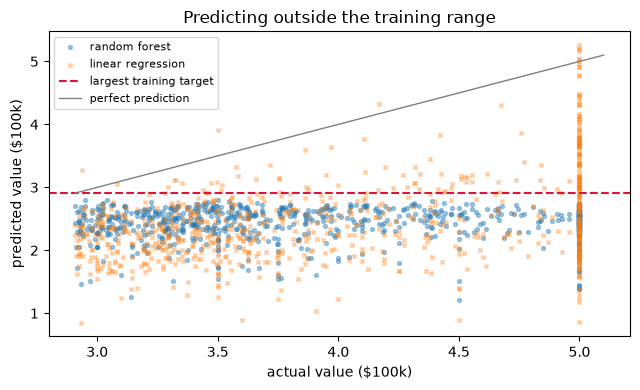

→ the forest's predictions stop at the red line; the linear model can go beyond it.


In [31]:
cutoff = yh_tr.quantile(0.8)
cheap = yh_tr < cutoff
expensive = yh_te >= cutoff
rf_cheap = RandomForestRegressor(n_estimators=100, min_samples_leaf=2, n_jobs=-1, random_state=SEED).fit(
    Xh_tr.loc[cheap], yh_tr.loc[cheap])
linear_cheap = make_pipeline(StandardScaler(), LinearRegression()).fit(Xh_tr.loc[cheap], yh_tr.loc[cheap])

extrapolation_rows = {}
for name, model in [("random forest", rf_cheap), ("linear regression", linear_cheap)]:
    prediction = model.predict(Xh_te.loc[expensive])
    extrapolation_rows[name] = {"max prediction": prediction.max(),
                                "share predicted ≥ cutoff": np.mean(prediction >= cutoff),
                                "RMSE on expensive districts": root_mean_squared_error(yh_te.loc[expensive], prediction)}
print(f"training targets are all below {cutoff:.2f} (max {yh_tr.loc[cheap].max():.2f}); "
      f"{int(expensive.sum()):,} test districts are at or above it (mean {yh_te.loc[expensive].mean():.2f})")
print(pd.DataFrame(extrapolation_rows).T.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4))
for name, model, marker in [("random forest", rf_cheap, "o"), ("linear regression", linear_cheap, "x")]:
    ax.scatter(yh_te.loc[expensive], model.predict(Xh_te.loc[expensive]), s=8, alpha=0.4, marker=marker, label=name)
ax.axhline(yh_tr.loc[cheap].max(), color="crimson", ls="--", label="largest training target")
ax.plot([cutoff, 5.1], [cutoff, 5.1], color="gray", lw=1, label="perfect prediction")
ax.set(xlabel="actual value ($100k)", ylabel="predicted value ($100k)", title="Predicting outside the training range")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print("→ the forest's predictions stop at the red line; " +
      ("the linear model can go beyond it." if extrapolation_rows["linear regression"]["max prediction"] > yh_tr.loc[cheap].max()
       else "here the linear model also stayed below it."))
del rf_cheap
gc.collect();

This matters for **trends**: prices, demand or sensor drift that rise past anything in the training data. Fixes: model the *change* (e.g. predict the ratio to last month), detrend first, or use a linear model or a linear-tree hybrid for that component.

### ✍️ Your Turn

Show that a regression forest's prediction is **exactly the mean of its trees' predictions**. For the first 100 test districts, average the predictions of every tree in `reg_forest.estimators_` and store the result in `mean_of_trees`. (Trees were fitted on NumPy arrays internally, so pass `Xh_te.iloc[:100].to_numpy()`.)

In [32]:
mean_of_trees = None  # TODO
check("mean_of_trees", mean_of_trees, reg_forest.predict(Xh_te.iloc[:100]),
      hint="np.mean([tree.predict(X_arr) for tree in reg_forest.estimators_], axis=0)")

⏳ mean_of_trees: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_arr = Xh_te.iloc[:100].to_numpy()
mean_of_trees = np.mean([tree.predict(X_arr) for tree in reg_forest.estimators_], axis=0)
check("mean_of_trees", mean_of_trees, reg_forest.predict(Xh_te.iloc[:100]))
```

The spread of the per-tree predictions also gives a rough sense of uncertainty, but it is **not** a calibrated prediction interval (use quantile regression or conformal prediction for that).
</details>

> 💡 **Interview angle:** "Why can't a random forest extrapolate?" — each leaf predicts an average of training targets, and the forest averages leaves, so predictions are confined to the training target range. For trending targets, model differences or ratios, or use linear components.

## 12. Random Forest vs Gradient Boosting: A Fair Head-to-Head 🟡

Same data (Covertype training sample), **same 5 folds**, default-ish settings. We compare a single tree, a random forest, extra trees and scikit-learn's `HistGradientBoostingClassifier` (a fast gradient-boosting implementation, covered in depth in [Gradient Boosting](10_Gradient_Boosting.ipynb)).

In [33]:
h2h_models = {
    "single tree (min_samples_leaf=5)": DecisionTreeClassifier(min_samples_leaf=5, random_state=SEED),
    "random forest (200 trees)": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "extra trees (200 trees)": ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=300, random_state=SEED),
}
h2h_rows, h2h_fold_scores = [], {}
for name, model in h2h_models.items():
    result = cross_validate(model, X_cov_tr, y_cov_tr, cv=cv5, scoring="accuracy")
    h2h_fold_scores[name] = result["test_score"]
    h2h_rows.append({"model": name, "CV accuracy": result["test_score"].mean(), "± std": result["test_score"].std(),
                     "fit s / fold": result["fit_time"].mean(), "predict s / fold": result["score_time"].mean()})
h2h_table = pd.DataFrame(h2h_rows).set_index("model").sort_values("CV accuracy", ascending=False)
print(h2h_table.round(4).to_string())

winner = h2h_table.index[0]
rf_name, gb_name = "random forest (200 trees)", "HistGradientBoosting"
fold_diff = h2h_fold_scores[gb_name] - h2h_fold_scores[rf_name]
print(f"\nwinner: {winner}")
print(f"HistGradientBoosting − random forest, fold by fold: {np.round(fold_diff, 4)} "
      f"(better on {int((fold_diff > 0).sum())}/5 folds, mean {fold_diff.mean():+.4f})")
print(f"random forest fits {h2h_table.loc[gb_name, 'fit s / fold'] / h2h_table.loc[rf_name, 'fit s / fold']:.1f}× faster than "
      f"HistGradientBoosting here (all {N_CPUS} cores) and predicts "
      f"{h2h_table.loc[rf_name, 'predict s / fold'] / h2h_table.loc[gb_name, 'predict s / fold']:.1f}× slower.")

                                  CV accuracy   ± std  fit s / fold  predict s / fold
model                                                                                
extra trees (200 trees)                0.8332  0.0055        0.1531            0.0297
random forest (200 trees)              0.8222  0.0070        0.1954            0.0325
HistGradientBoosting                   0.7692  0.0103        0.6898            0.0052
single tree (min_samples_leaf=5)       0.7427  0.0108        0.0638            0.0011

winner: extra trees (200 trees)
HistGradientBoosting − random forest, fold by fold: [-0.0637 -0.055  -0.0467 -0.059  -0.0407] (better on 0/5 folds, mean -0.0530)
random forest fits 3.5× faster than HistGradientBoosting here (all 15 cores) and predicts 6.3× slower.


Because all models saw identical folds, the **fold-by-fold differences** are a fair, paired comparison, much more trustworthy than comparing two single numbers.

Here the tree ensembles beat an **untuned** `HistGradientBoostingClassifier` clearly. Covertype rewards very deep trees (Section 7b: depth 8 → ~0.72, fully grown → ~0.835), which is exactly what a forest grows by default, while the booster's defaults (31-leaf trees, learning rate 0.1, early stopping) are conservative. A tuned booster can narrow the gap, but that tuning is the cost in the table below. Don't generalize from one dataset: rerun this kind of comparison instead of assuming a winner.

**When to choose which**

| Situation | Random forest | Gradient boosting |
|---|---|---|
| Strong baseline with almost no tuning | ✅ defaults are good | needs learning rate + early stopping |
| Squeezing out the best accuracy on tabular data | usually a little behind | ✅ usually wins when tuned |
| Noisy labels / many outliers | ✅ averaging is robust | chases noise; needs care |
| Training on many cores | ✅ trees fully independent | parallel only inside each tree |
| Small model, low latency | large deep trees | ✅ shallow trees, usually much smaller |
| Free validation estimate | ✅ OOB score | needs a validation set |
| Calibrated probabilities | often under-confident at the extremes | log-loss objective, usually better |
| Extrapolating trends | ❌ | ❌ (both are tree ensembles) |

> 💡 **Interview angle:** "Random forest or XGBoost?" — start with a random forest when you want a robust baseline fast (few knobs, OOB score, noisy data); move to gradient boosting when accuracy, model size or latency matter and you can afford tuning with early stopping. Always compare on the **same folds**.

## 🔧 Build It From Scratch

### 1) A random forest that matches scikit-learn bit for bit

The recipe is short: for each tree, draw a bootstrap sample, grow a `DecisionTreeClassifier` that tries `max_features` random features at each split, then average the trees' class probabilities.

To match `RandomForestClassifier` **exactly** we copy three implementation details (read from the installed scikit-learn source):
1. **Seeds:** one `RandomState(random_state)` produces an integer seed per tree; that seed drives both the bootstrap draw and the tree's feature sampling.
2. **Bootstrap as counts:** instead of copying rows, scikit-learn passes `sample_weight = how many times each row was drawn`. Rows drawn 0 times get weight 0. That's mathematically the same training set, and it saves memory.
3. **Soft voting:** the forest's prediction is the argmax of the **mean predicted probabilities**, not a majority vote of labels.

In [34]:
MAX_INT = np.iinfo(np.int32).max


class ScratchRandomForestClassifier:
    """Bagging + random features per split, seeded exactly like scikit-learn's RandomForestClassifier."""

    def __init__(self, n_estimators=100, max_features="sqrt", random_state=0, bootstrap_as="counts"):
        self.n_estimators, self.max_features = n_estimators, max_features
        self.random_state, self.bootstrap_as = random_state, bootstrap_as

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float32)
        self.classes_, y_encoded = np.unique(np.asarray(y), return_inverse=True)
        n_rows = len(X)
        seed_stream = np.random.RandomState(self.random_state)
        self.trees_, self.bootstrap_rows_ = [], []
        for _ in range(self.n_estimators):
            seed = seed_stream.randint(MAX_INT)                                # one seed per tree
            rows = np.random.RandomState(seed).randint(0, n_rows, n_rows)      # n draws with replacement
            tree = DecisionTreeClassifier(max_features=self.max_features, random_state=seed)
            if self.bootstrap_as == "counts":
                tree.fit(X, y_encoded, sample_weight=np.bincount(rows, minlength=n_rows))
            else:                                                             # the "textbook" way: copy the rows
                tree.fit(X[rows], y_encoded[rows])
            self.trees_.append(tree)
            self.bootstrap_rows_.append(rows)
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        total = np.zeros((len(X), len(self.classes_)))
        for tree in self.trees_:
            total[:, tree.classes_.astype(int)] += tree.predict_proba(X)      # soft vote
        return total / len(self.trees_)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

    def predict_hard_vote(self, X):
        X = np.asarray(X, dtype=np.float32)
        votes = np.zeros((len(X), len(self.classes_)))
        for tree in self.trees_:
            votes[np.arange(len(X)), tree.predict(X).astype(int)] += 1       # one vote per tree
        return self.classes_[votes.argmax(axis=1)]


start = time.perf_counter()
scratch_rf = ScratchRandomForestClassifier(n_estimators=60, random_state=SEED).fit(X_cov_tr, y_cov_tr)
scratch_seconds = time.perf_counter() - start
start = time.perf_counter()
sklearn_rf = RandomForestClassifier(n_estimators=60, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
sklearn_seconds = time.perf_counter() - start

proba_diff = np.abs(scratch_rf.predict_proba(X_cov_val) - sklearn_rf.predict_proba(X_cov_val)).max()
assert proba_diff < 1e-12, f"probabilities differ by {proba_diff}"
assert np.array_equal(scratch_rf.predict(X_cov_val), sklearn_rf.predict(X_cov_val))
assert all(np.array_equal(np.sort(ours), np.sort(theirs))
           for ours, theirs in zip(scratch_rf.bootstrap_rows_, sklearn_rf.estimators_samples_))
print(f"✅ scratch forest == RandomForestClassifier: max |Δ probability| = {proba_diff:.1e}, identical predictions "
      f"and identical bootstrap samples for all {len(scratch_rf.trees_)} trees")
print(f"fit time: scratch (1 core) {scratch_seconds:.1f}s vs scikit-learn ({N_CPUS} cores) {sklearn_seconds:.1f}s")

✅ scratch forest == RandomForestClassifier: max |Δ probability| = 0.0e+00, identical predictions and identical bootstrap samples for all 60 trees
fit time: scratch (1 core) 0.7s vs scikit-learn (15 cores) 0.1s


In [35]:
indexed_rf = ScratchRandomForestClassifier(n_estimators=60, random_state=SEED, bootstrap_as="rows").fit(X_cov_tr, y_cov_tr)
acc_counts = accuracy_score(y_cov_val, scratch_rf.predict(X_cov_val))
acc_rows = accuracy_score(y_cov_val, indexed_rf.predict(X_cov_val))
hard = scratch_rf.predict_hard_vote(X_cov_val)
print(f"bootstrap as sample-weight counts: val accuracy {acc_counts:.4f}")
print(f"bootstrap by copying rows       : val accuracy {acc_rows:.4f} "
      f"(same samples, agree on {np.mean(indexed_rf.predict(X_cov_val) == scratch_rf.predict(X_cov_val)):.1%} of rows)")
print(f"hard majority vote              : val accuracy {accuracy_score(y_cov_val, hard):.4f} "
      f"(agrees with the soft vote on {np.mean(hard == scratch_rf.predict(X_cov_val)):.1%} of rows)")
del scratch_rf, sklearn_rf, indexed_rf
gc.collect();

bootstrap as sample-weight counts: val accuracy 0.8360
bootstrap by copying rows       : val accuracy 0.8360 (same samples, agree on 100.0% of rows)
hard majority vote              : val accuracy 0.8360 (agrees with the soft vote on 100.0% of rows)


Copying rows gave the same predictions here, but the two versions are not guaranteed to be bit-identical: rows with weight 0 still exist in the counts version, so a split threshold (a midpoint between neighbouring values) can land in a slightly different place. Counts also avoid copying the data for every tree. Hard and soft voting can only disagree on rows where the trees are split between classes; with 60 fully grown trees on this data, that didn't change any prediction.

### 2) The out-of-bag score, recomputed from `estimators_samples_`

**Verified definition** (from `BaggingClassifier._set_oob_score` in the installed scikit-learn): for every estimator, take the rows **not** in `estimators_samples_`, add its `predict_proba` (on that estimator's `estimators_features_`) to those rows' totals; OOB class = argmax of the totals; `oob_score_` = accuracy. If a base estimator has no `predict_proba`, it adds one vote per predicted class instead.

In [36]:
bag_oob = BaggingClassifier(DecisionTreeClassifier(max_features="sqrt"), n_estimators=60, oob_score=True, n_jobs=-1,
                            random_state=SEED).fit(X_cov_tr, y_cov_tr)


def oob_accuracy(bagging, X, y, vote="soft"):
    """OOB accuracy from a fitted BaggingClassifier's bootstrap indices and feature subsets."""
    X, y = np.asarray(X), np.asarray(y)
    n_rows = len(X)
    totals = np.zeros((n_rows, len(bagging.classes_)))
    for estimator, rows, features in zip(bagging.estimators_, bagging.estimators_samples_, bagging.estimators_features_):
        out_of_bag = np.ones(n_rows, dtype=bool)
        out_of_bag[rows] = False                                          # rows this estimator never saw
        X_oob = X[out_of_bag][:, features]
        if vote == "soft":
            totals[out_of_bag] += estimator.predict_proba(X_oob)
        else:
            totals[np.flatnonzero(out_of_bag), estimator.predict(X_oob).astype(int)] += 1
    covered = (totals.sum(axis=1) > 0).mean()
    return accuracy_score(y, bagging.classes_[totals.argmax(axis=1)]), covered


my_oob, covered = oob_accuracy(bag_oob, X_cov_tr, y_cov_tr)
assert my_oob == bag_oob.oob_score_, (my_oob, bag_oob.oob_score_)
hard_oob, _ = oob_accuracy(bag_oob, X_cov_tr, y_cov_tr, vote="hard")
print(f"✅ scratch OOB accuracy {my_oob:.6f} == BaggingClassifier.oob_score_ {bag_oob.oob_score_:.6f} "
      f"({covered:.2%} of rows were out-of-bag for at least one of the 60 trees)")
print(f"a hard-vote OOB would give {hard_oob:.6f} — "
      + ("a different number, so the soft-vote definition matters" if hard_oob != my_oob
         else "the same number on this data (fully grown trees output 0/1 probabilities, so soft and hard votes coincide), "
              "but with min_samples_leaf > 1 the two definitions can differ"))
del bag_oob
gc.collect();

✅ scratch OOB accuracy 0.817667 == BaggingClassifier.oob_score_ 0.817667 (100.00% of rows were out-of-bag for at least one of the 60 trees)
a hard-vote OOB would give 0.817667 — the same number on this data (fully grown trees output 0/1 probabilities, so soft and hard votes coincide), but with min_samples_leaf > 1 the two definitions can differ


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Judging a forest by its training accuracy

In [37]:
rf_pitfall = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
print(f"❌ training accuracy  : {rf_pitfall.score(X_cov_tr, y_cov_tr):.4f}  ← fully grown trees memorize; this says nothing")
print(f"✅ OOB accuracy       : {rf_pitfall.oob_score_:.4f}")
print(f"✅ validation accuracy: {rf_pitfall.score(X_cov_val, y_cov_val):.4f}")
del rf_pitfall

❌ training accuracy  : 1.0000  ← fully grown trees memorize; this says nothing
✅ OOB accuracy       : 0.8249
✅ validation accuracy: 0.8352


### ❌ Pitfall 2 — Asking for an OOB score without bootstrap samples

`ExtraTreesClassifier` uses `bootstrap=False` by default, so there are no out-of-bag rows.

In [38]:
try:
    ExtraTreesClassifier(n_estimators=50, oob_score=True).fit(X_small, y_small)
except ValueError as err:
    print("❌", err)
et_with_oob = ExtraTreesClassifier(n_estimators=50, bootstrap=True, oob_score=True, n_jobs=-1, random_state=SEED).fit(X_small, y_small)
print(f"✅ bootstrap=True → OOB accuracy {et_with_oob.oob_score_:.4f}")
del et_with_oob

❌ Out of bag estimation only available if bootstrap=True
✅ bootstrap=True → OOB accuracy 0.7482


### ❌ Pitfall 3 — An OOB score from too few trees

With 5 trees, a row is out-of-bag for **none** of them with probability $0.632^5 \approx 10\%$. Those rows get no OOB prediction at all, and the score is computed anyway.

In [39]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    tiny_forest = RandomForestClassifier(n_estimators=5, oob_score=True, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
no_prediction = np.mean(tiny_forest.oob_decision_function_.sum(axis=1) == 0)
print(f"❌ 5 trees: warning = {[str(w.message)[:80] for w in caught]}")
print(f"   {no_prediction:.1%} of rows had no OOB prediction (expected ≈ {0.632 ** 5:.1%}); OOB accuracy {tiny_forest.oob_score_:.4f}")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    enough_forest = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
print(f"✅ 100 trees: {len(caught)} warnings, OOB accuracy {enough_forest.oob_score_:.4f}")
del tiny_forest, enough_forest

❌ 5 trees: warning = ['Some inputs do not have OOB scores. This probably means too few trees were used ']
   10.0% of rows had no OOB prediction (expected ≈ 10.1%); OOB accuracy 0.6792


✅ 100 trees: 0 warnings, OOB accuracy 0.8249


### ❌ Pitfall 4 — Copying `max_features="auto"` from an old tutorial

In [40]:
try:
    RandomForestClassifier(max_features="auto").fit(X_small, y_small)
except ValueError as err:                                   # InvalidParameterError is a ValueError
    print("❌", type(err).__name__, "—", str(err)[:170])
print("✅ use max_features='sqrt' for classification (the old 'auto' meant sqrt for classifiers but 1.0 for regressors)")
print("   RandomForestClassifier default:", RandomForestClassifier().max_features,
      "| RandomForestRegressor default:", RandomForestRegressor().max_features)

❌ InvalidParameterError — The 'max_features' parameter of RandomForestClassifier must be an int in the range [1, inf), a float in the range (0.0, 1.0], a str among {'sqrt', 'log2'} or None. Got 'a
✅ use max_features='sqrt' for classification (the old 'auto' meant sqrt for classifiers but 1.0 for regressors)
   RandomForestClassifier default: sqrt | RandomForestRegressor default: 1.0


### ❌ Pitfall 5 — Forgetting `random_state`: results you can't reproduce

In [41]:
proba_a = RandomForestClassifier(n_estimators=50, n_jobs=-1).fit(X_small, y_small).predict_proba(X_cov_val)
proba_b = RandomForestClassifier(n_estimators=50, n_jobs=-1).fit(X_small, y_small).predict_proba(X_cov_val)
print(f"❌ no random_state: identical probabilities? {np.array_equal(proba_a, proba_b)} | "
      f"predicted classes differ on {np.mean(proba_a.argmax(1) != proba_b.argmax(1)):.1%} of rows")
proba_c = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED).fit(X_small, y_small).predict_proba(X_cov_val)
proba_d = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED).fit(X_small, y_small).predict_proba(X_cov_val)
print(f"✅ random_state=SEED: identical probabilities? {np.array_equal(proba_c, proba_d)} (even with n_jobs=-1)")

❌ no random_state: identical probabilities? False | predicted classes differ on 7.9% of rows


✅ random_state=SEED: identical probabilities? True (even with n_jobs=-1)


### ❌ Pitfall 6 — A category at prediction time that training never saw

Real traffic contains new values. A default `OrdinalEncoder` crashes the whole request.

In [42]:
adult_cat_cols = X_imp_tr.select_dtypes("category").columns.tolist()
new_person = X_imp_val.iloc[[0]].assign(**{"native-country": "Atlantis"})     # a country absent from training

strict = make_pipeline(make_column_transformer((OrdinalEncoder(), adult_cat_cols), remainder="passthrough"),
                       RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED)).fit(X_imp_tr, y_imp_tr)
try:
    strict.predict(new_person)
except ValueError as err:
    print("❌", str(err)[:120])

tolerant = make_pipeline(make_tree_preprocessor(), RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=SEED)).fit(
    X_imp_tr, y_imp_tr)
print(f"✅ handle_unknown='use_encoded_value' → P(>50K) = {tolerant.predict_proba(new_person)[0, 1]:.3f} "
      "(unknown category encoded as -1)")
del strict, tolerant
gc.collect();

❌ Found unknown categories ['Atlantis'] in column 7 during transform


✅ handle_unknown='use_encoded_value' → P(>50K) = 0.120 (unknown category encoded as -1)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Out-of-bag probability
Write `oob_fraction(n)`: the probability that a given row is **not** in a bootstrap sample of size `n` drawn from `n` rows.

In [43]:
def oob_fraction(n):
    return None  # TODO


check("oob_fraction", oob_fraction(1000), 0.36769542, hint="(1 - 1/n) ** n")

⏳ oob_fraction: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def oob_fraction(n):
    return (1 - 1 / n) ** n


check("oob_fraction", oob_fraction(1000), 0.36769542)
```
</details>

### 🟢 Exercise 2 — Variance of an average of correlated trees
Write `forest_variance(rho, sigma2, n_trees)` implementing $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$.

In [44]:
def forest_variance(rho, sigma2, n_trees):
    return None  # TODO


check("forest_variance", forest_variance(0.2, 4.0, 50), 0.864, hint="rho * sigma2 + (1 - rho) * sigma2 / n_trees")

⏳ forest_variance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def forest_variance(rho, sigma2, n_trees):
    return rho * sigma2 + (1 - rho) * sigma2 / n_trees


check("forest_variance", forest_variance(0.2, 4.0, 50), 0.864)
```

0.8 is the floor; 50 trees add only 0.064 on top. Going to 500 trees would save just 0.058 more.
</details>

### 🟢 Exercise 3 — Free validation
Fit `RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=SEED)` on `X_cov_tr, y_cov_tr` and store its OOB accuracy in `oob_acc`. The checker requires more than 0.80.

In [45]:
oob_acc = None  # TODO
check("oob_acc_above_0.80", None if oob_acc is None else bool(oob_acc > 0.80), True, hint="Read the fitted forest's .oob_score_")

⏳ oob_acc_above_0.80: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
oob_acc = RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr).oob_score_
print(f"OOB accuracy {oob_acc:.4f}")
check("oob_acc_above_0.80", bool(oob_acc > 0.80), True)
```
</details>

### 🟡 Exercise 4 — Hard voting with scikit-learn's own trees
Using the 200 trees in `rf_oob.estimators_`, compute a **majority vote** (each tree predicts one class) for every row of `X_cov_val` and store the predicted **species labels** (1–7) in `hard_pred`.

Two traps: the trees were fitted on **encoded** labels 0–6 (map back with `rf_oob.classes_`), and on NumPy arrays (pass `X_cov_val.to_numpy()` to avoid a feature-name warning). The checker requires real labels and ≥ 95% agreement with `rf_oob.predict`.

In [46]:
hard_pred = None  # TODO

hard_ok = None
if hard_pred is not None:
    hard_pred = np.asarray(hard_pred)
    hard_ok = bool(set(np.unique(hard_pred)) <= set(rf_oob.classes_) and np.mean(hard_pred == rf_oob.predict(X_cov_val)) >= 0.95)
check("hard_vote", hard_ok, True, hint="Stack tree.predict(X_arr).astype(int) → count votes per row with np.bincount(..., minlength=7) → argmax → rf_oob.classes_[...]")

⏳ hard_vote: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_arr = X_cov_val.to_numpy()
tree_votes = np.stack([tree.predict(X_arr).astype(int) for tree in rf_oob.estimators_])    # (trees, rows)
vote_counts = np.apply_along_axis(np.bincount, 0, tree_votes, minlength=len(rf_oob.classes_))  # (classes, rows)
hard_pred = rf_oob.classes_[vote_counts.argmax(axis=0)]

agreement = np.mean(hard_pred == rf_oob.predict(X_cov_val))
print(f"hard vote agrees with the soft vote on {agreement:.2%} of rows | "
      f"accuracy hard {accuracy_score(y_cov_val, hard_pred):.4f} vs soft {rf_oob.score(X_cov_val, y_cov_val):.4f}")
hard_ok = bool(set(np.unique(hard_pred)) <= set(rf_oob.classes_) and agreement >= 0.95)
check("hard_vote", hard_ok, True)
```
</details>

### 🟡 Exercise 5 — The smallest forest that's good enough
For `min_samples_leaf` in `[1, 2, 5, 10, 20]`, fit `RandomForestClassifier(n_estimators=100, oob_score=True, n_jobs=-1, random_state=SEED)` on the Covertype training sample. Store `leaf_results = {leaf: (oob_score, forest_mb(model))}`, then set `chosen_leaf` to the setting with the **smallest memory** whose OOB accuracy is within **0.01** of the best one.

In [47]:
leaf_results = None  # TODO: dict {min_samples_leaf: (oob accuracy, memory MB)}
chosen_leaf = None   # TODO

leaf_ok = None
if leaf_results is not None and chosen_leaf is not None:
    best_oob = max(score for score, _ in leaf_results.values())
    acceptable = [leaf for leaf, (score, _) in leaf_results.items() if score >= best_oob - 0.01]
    leaf_ok = bool(set(leaf_results) == {1, 2, 5, 10, 20}
                   and chosen_leaf == min(acceptable, key=lambda leaf: leaf_results[leaf][1]))
check("chosen_leaf", leaf_ok, True, hint="Filter settings with oob >= best - 0.01, then take the one with the smallest memory.")

⏳ chosen_leaf: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
leaf_results = {}
for leaf in [1, 2, 5, 10, 20]:
    model = RandomForestClassifier(n_estimators=100, min_samples_leaf=leaf, oob_score=True, n_jobs=-1,
                                   random_state=SEED).fit(X_cov_tr, y_cov_tr)
    leaf_results[leaf] = (model.oob_score_, forest_mb(model))
    del model
best_oob = max(score for score, _ in leaf_results.values())
chosen_leaf = min((leaf for leaf, (score, _) in leaf_results.items() if score >= best_oob - 0.01),
                  key=lambda leaf: leaf_results[leaf][1])
for leaf, (score, mb) in leaf_results.items():
    print(f"min_samples_leaf={leaf:>2}: OOB {score:.4f}, {mb:6.1f} MB")
print("chosen:", chosen_leaf)

acceptable = [leaf for leaf, (score, _) in leaf_results.items() if score >= best_oob - 0.01]
leaf_ok = bool(set(leaf_results) == {1, 2, 5, 10, 20} and chosen_leaf == min(acceptable, key=lambda leaf: leaf_results[leaf][1]))
check("chosen_leaf", leaf_ok, True)
```

OOB lets you make this size/accuracy decision without spending the validation set.
</details>

### 🔴 Exercise 6 — Permutation importance from scratch (interview classic)

Implement `my_permutation_importance(model, X, y, n_repeats, random_state)` returning an array `(n_features, n_repeats)` of accuracy drops that matches `sklearn.inspection.permutation_importance` **exactly**. The installed version does this (read from its source):
1. `baseline = model.score(X, y)`.
2. Draw **one** seed: `seed = np.random.RandomState(random_state).randint(np.iinfo(np.int32).max + 1)`.
3. For **each column**: copy `X` once, start a fresh `rng = np.random.RandomState(seed)` and `idx = np.arange(n_rows)`. Then repeat `n_repeats` times: `rng.shuffle(idx)` (in place), set the column of the copy to **its current values** reordered by `idx`, and record `baseline − model.score(X_copy, y)`.

In [48]:
perm_model = RandomForestClassifier(n_estimators=40, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
X_perm, y_perm = X_cov_val.iloc[:1_500], y_cov_val.iloc[:1_500]


def my_permutation_importance(model, X, y, n_repeats, random_state):
    # TODO: return a NumPy array of shape (n_features, n_repeats)
    return None


mine = my_permutation_importance(perm_model, X_perm, y_perm, n_repeats=2, random_state=SEED)
check("permutation_importance", mine,
      permutation_importance(perm_model, X_perm, y_perm, n_repeats=2, random_state=SEED).importances,
      hint="Copy X once per column; X_copy[col] = X_copy[col].to_numpy()[idx] after each rng.shuffle(idx).")

⏳ permutation_importance: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
perm_model = RandomForestClassifier(n_estimators=40, n_jobs=-1, random_state=SEED).fit(X_cov_tr, y_cov_tr)
X_perm, y_perm = X_cov_val.iloc[:1_500], y_cov_val.iloc[:1_500]


def my_permutation_importance(model, X, y, n_repeats, random_state):
    baseline = model.score(X, y)
    seed = np.random.RandomState(random_state).randint(np.iinfo(np.int32).max + 1)
    drops = np.zeros((X.shape[1], n_repeats))
    for j, column in enumerate(X.columns):
        X_copy = X.copy()
        rng, idx = np.random.RandomState(seed), np.arange(len(X))
        for k in range(n_repeats):
            rng.shuffle(idx)
            X_copy[column] = X_copy[column].to_numpy()[idx]
            drops[j, k] = baseline - model.score(X_copy, y)
    return drops


mine = my_permutation_importance(perm_model, X_perm, y_perm, n_repeats=2, random_state=SEED)
check("permutation_importance", mine,
      permutation_importance(perm_model, X_perm, y_perm, n_repeats=2, random_state=SEED).importances)
top = pd.Series(mine.mean(axis=1), index=X_perm.columns).sort_values(ascending=False)
print("top 5 features by accuracy drop:\n", top.head(5).round(4).to_string())
```

Interview follow-ups: it's model-agnostic, needs no retraining, must use **held-out** data, costs `n_features × n_repeats` extra predictions, and splits credit between correlated features (drop-column importance or grouped permutation avoids that, at a higher cost).
</details>

## 🚀 Mini Project: Adult Income With a Forest, Extra Trees and a Pruned Tree

**Goal:** predict whether a person earns more than \$50K. Compare a **random forest**, **extra trees** and a **cost-complexity-pruned single tree** on the **same 5 CV folds**, pick a winner by CV ROC-AUC, **audit its feature importances** (MDI vs permutation on a validation split), and evaluate it **once** on the untouched test set.

**Steps:** folds and baseline → tune each model on the same folds → compare → importance audit → single test evaluation → conclusions.

### Step 1 — Folds and baseline

`X_ad_tr` (80%) is for all decisions; `X_ad_te` (20%) was split off in Section 9 and hasn't been used.

In [49]:
fold_indices = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X_ad_tr, y_ad_tr))
print(f"train {len(X_ad_tr):,} rows · test {len(X_ad_te):,} rows · positive rate train {y_ad_tr.mean():.3f} / test {y_ad_te.mean():.3f}")
print("same 5 folds for every model; fold sizes:", [len(valid) for _, valid in fold_indices])
print(f"baseline: always predict '≤50K' → accuracy {1 - y_ad_tr.mean():.4f}, ROC-AUC 0.5")

train 39,073 rows · test 9,769 rows · positive rate train 0.239 / test 0.239
same 5 folds for every model; fold sizes: [7815, 7815, 7815, 7814, 7814]
baseline: always predict '≤50K' → accuracy 0.7607, ROC-AUC 0.5


### Step 2 — Tune each model on the same folds

A small grid per model. `ccp_alpha` is cost-complexity pruning: a tree is pruned back while the impurity it saves per removed leaf is below `ccp_alpha`.

In [50]:
candidates = {
    "pruned tree": (DecisionTreeClassifier(random_state=SEED),
                    {"model__ccp_alpha": [0.0, 1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3]}),
    "random forest": (RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
                      {"model__min_samples_leaf": [1, 3, 10], "model__max_features": ["sqrt", 0.5]}),
    "extra trees": (ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
                    {"model__min_samples_leaf": [1, 3, 10], "model__max_features": ["sqrt", 0.5]}),
}
searches, project_rows = {}, []
for name, (estimator, grid) in candidates.items():
    pipeline = Pipeline([("prep", make_tree_preprocessor()), ("model", estimator)])
    start = time.perf_counter()
    search = GridSearchCV(pipeline, grid, cv=fold_indices, scoring={"roc_auc": "roc_auc", "accuracy": "accuracy"},
                          refit=False).fit(X_ad_tr, y_ad_tr)
    results = pd.DataFrame(search.cv_results_)
    best_i = int(results["mean_test_roc_auc"].idxmax())
    searches[name] = results
    project_rows.append({
        "model": name, "best params": {k.replace("model__", ""): v for k, v in results.loc[best_i, "params"].items()},
        "CV ROC-AUC": results.loc[best_i, "mean_test_roc_auc"], "± std": results.loc[best_i, "std_test_roc_auc"],
        "CV accuracy": results.loc[best_i, "mean_test_accuracy"], "fit s / fold": results.loc[best_i, "mean_fit_time"],
        "predict s / fold": results.loc[best_i, "mean_score_time"], "search s": time.perf_counter() - start,
        "fold AUCs": results.loc[best_i, [f"split{i}_test_roc_auc" for i in range(5)]].to_numpy(dtype=float),
    })
    print(f"{name:14s} searched {len(results)} configs × 5 folds in {project_rows[-1]['search s']:.1f}s")

pruned tree    searched 7 configs × 5 folds in 4.7s


random forest  searched 6 configs × 5 folds in 13.4s


extra trees    searched 6 configs × 5 folds in 10.1s


### Step 3 — Compare on the same folds and pick the winner

                                                    best params  CV ROC-AUC   ± std  CV accuracy  fit s / fold  predict s / fold  search s
model                                                                                                                                     
random forest  {'max_features': 'sqrt', 'min_samples_leaf': 10}      0.9165  0.0028       0.8624        0.2657            0.0748   13.4016
extra trees        {'max_features': 0.5, 'min_samples_leaf': 3}      0.9118  0.0026       0.8597        0.2935            0.0773   10.1137
pruned tree                               {'ccp_alpha': 0.0001}      0.9020  0.0045       0.8566        0.1190            0.0188    4.6786

🏆 winner by CV ROC-AUC: random forest {'max_features': 'sqrt', 'min_samples_leaf': 10}
vs extra trees, fold by fold: [0.005  0.0051 0.0043 0.0054 0.004 ] → better on 5/5 folds, mean +0.0048


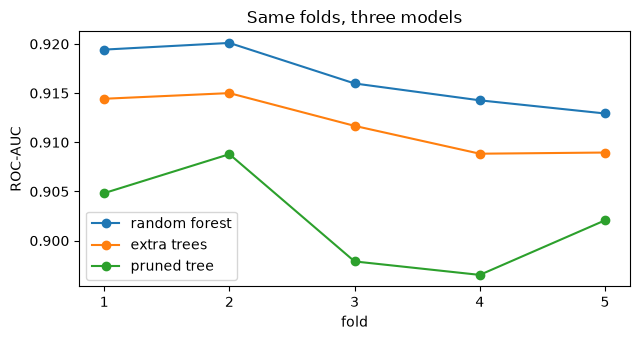

In [51]:
project_table = pd.DataFrame(project_rows).set_index("model").sort_values("CV ROC-AUC", ascending=False)
print(project_table.drop(columns=["fold AUCs"]).round(4).to_string())

winner_name = project_table.index[0]
runner_up = project_table.index[1]
paired = project_table.loc[winner_name, "fold AUCs"] - project_table.loc[runner_up, "fold AUCs"]
print(f"\n🏆 winner by CV ROC-AUC: {winner_name} {project_table.loc[winner_name, 'best params']}")
print(f"vs {runner_up}, fold by fold: {np.round(paired, 4)} → better on {int((paired > 0).sum())}/5 folds, mean {paired.mean():+.4f}")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
for name in project_table.index:
    ax.plot(range(1, 6), project_table.loc[name, "fold AUCs"], "o-", label=name)
ax.set(xlabel="fold", ylabel="ROC-AUC", title="Same folds, three models", xticks=range(1, 6))
ax.legend()
plt.tight_layout()
plt.show()

### Step 4 — Importance audit: MDI vs permutation (validation split, not test)

We refit the winner's configuration on the Section 9 training part (`X_imp_tr`) and audit it on `X_imp_val`. Features whose ranks differ a lot between the two methods deserve suspicion before anyone tells a stakeholder "this drives income".

In [52]:
winner_params = project_table.loc[winner_name, "best params"]


def winner_pipeline():
    """A fresh, unfitted pipeline with the winning model and its best hyperparameters."""
    return Pipeline([("prep", make_tree_preprocessor()), ("model", clone(candidates[winner_name][0]).set_params(**winner_params))])


audit_model = winner_pipeline().fit(X_imp_tr, y_imp_tr)
audit_mdi = pd.Series(audit_model[-1].feature_importances_, index=audit_model[:-1].get_feature_names_out())
audit_perm = permutation_importance(audit_model, X_imp_val.iloc[:4_000], y_imp_val.iloc[:4_000], scoring="roc_auc",
                                    n_repeats=5, random_state=SEED)
audit = pd.DataFrame({"MDI": audit_mdi,
                      "permutation (val AUC drop)": pd.Series(audit_perm.importances_mean, index=X_imp_val.columns),
                      "perm std": pd.Series(audit_perm.importances_std, index=X_imp_val.columns)})
audit["MDI rank"] = audit["MDI"].rank(ascending=False).astype(int)
audit["perm rank"] = audit["permutation (val AUC drop)"].rank(ascending=False).astype(int)
audit["rank gap"] = audit["MDI rank"] - audit["perm rank"]
print(audit.sort_values("perm rank").round(4).to_string())

spearman = audit["MDI"].corr(audit["permutation (val AUC drop)"], method="spearman")
overrated = audit.index[audit["rank gap"] <= -4].tolist()
useless = audit.index[audit["permutation (val AUC drop)"] <= 2 * audit["perm std"]].tolist()
print(f"\nSpearman rank correlation MDI vs permutation: {spearman:.2f}")
print(f"ranked ≥4 places higher by MDI than by permutation (likely cardinality bias): {overrated or 'none'}")
print(f"permutation drop within 2 std of zero (no measurable use on validation): {useless or 'none'}")

                   MDI  permutation (val AUC drop)  perm std  MDI rank  perm rank  rank gap
capital-gain    0.1790                      0.0464    0.0015         2          1         1
relationship    0.1832                      0.0353    0.0018         1          2        -1
education-num   0.1525                      0.0288    0.0025         3          3         0
marital-status  0.1312                      0.0233    0.0014         4          4         0
age             0.0872                      0.0214    0.0026         5          5         0
hours-per-week  0.0593                      0.0132    0.0009         6          6         0
capital-loss    0.0454                      0.0072    0.0007         7          7         0
occupation      0.0410                      0.0054    0.0015         8          8         0
education       0.0385                      0.0028    0.0011        10          9         1
sex             0.0208                      0.0021    0.0007        11         1

### Step 5 — The one and only test evaluation

All decisions are frozen. Refit the winner's configuration on the **full** training split and score the test set once.

In [53]:
final_model = winner_pipeline()
start = time.perf_counter()
final_model.fit(X_ad_tr, y_ad_tr)
final_fit_seconds = time.perf_counter() - start
start = time.perf_counter()
test_proba = final_model.predict_proba(X_ad_te)[:, 1]
predict_seconds = time.perf_counter() - start
test_metrics = {
    "ROC-AUC": roc_auc_score(y_ad_te, test_proba),
    "accuracy @0.5": accuracy_score(y_ad_te, (test_proba >= 0.5).astype(int)),
    "log-loss": log_loss(y_ad_te, np.clip(test_proba, 1e-6, 1 - 1e-6)),
    "majority-class accuracy": 1 - y_ad_te.mean(),
    "model pickle MB": pickle_mb(final_model),
    "ms per 1,000 predictions": 1000 * predict_seconds / len(X_ad_te) * 1000,
}
for metric, value in test_metrics.items():
    print(f"{metric:26s} {value:.4f}")

ROC-AUC                    0.9185
accuracy @0.5              0.8660
log-loss                   0.2974
majority-class accuracy    0.7607
model pickle MB            25.7000
ms per 1,000 predictions   3.9757


### Step 6 — Conclusions (computed)

In [54]:
cv_auc = project_table.loc[winner_name, "CV ROC-AUC"]
gap = test_metrics["ROC-AUC"] - cv_auc
tree_auc = project_table.loc["pruned tree", "CV ROC-AUC"]
print(f"1. Winner: {winner_name} with {winner_params}; CV ROC-AUC {cv_auc:.4f} (± {project_table.loc[winner_name, '± std']:.4f}).")
print(f"2. Runner-up {runner_up} was {paired.mean():.4f} AUC behind on average and better on {int((paired < 0).sum())}/5 folds → "
      + ("a consistent win." if (paired > 0).all() else "close enough that speed or size could decide."))
print(f"3. Ensembles vs the best pruned tree: +{cv_auc - tree_auc:.4f} CV AUC.")
print(f"4. Test ROC-AUC {test_metrics['ROC-AUC']:.4f} vs CV {cv_auc:.4f} (gap {gap:+.4f}) → "
      + ("CV was a reliable guide." if abs(gap) < 0.01 else "check for distribution differences between train and test."))
print(f"5. Importance audit: MDI and permutation ranks correlate at {spearman:.2f}; MDI-overrated features: {overrated or 'none'}.")
print(f"6. Cost: {test_metrics['model pickle MB']:.1f} MB model, fit {final_fit_seconds:.1f}s, "
      f"{test_metrics['ms per 1,000 predictions']:.1f} ms per 1,000 predictions.")
del searches, audit_model
gc.collect();

1. Winner: random forest with {'max_features': 'sqrt', 'min_samples_leaf': 10}; CV ROC-AUC 0.9165 (± 0.0028).
2. Runner-up extra trees was 0.0048 AUC behind on average and better on 0/5 folds → a consistent win.
3. Ensembles vs the best pruned tree: +0.0145 CV AUC.
4. Test ROC-AUC 0.9185 vs CV 0.9165 (gap +0.0019) → CV was a reliable guide.
5. Importance audit: MDI and permutation ranks correlate at 0.97; MDI-overrated features: none.
6. Cost: 25.7 MB model, fit 0.3s, 4.0 ms per 1,000 predictions.


**Stretch goals**
1. Add `HistGradientBoostingClassifier` (with `categorical_features="from_dtype"`) to the same folds. Does it beat the forest, and by how much per fold?
2. Drop the features flagged as useless by permutation importance, re-run CV, and check whether the score holds.
3. Tune the decision threshold for F1 using **OOB** probabilities (`oob_score=True`) instead of a validation split.
4. Compare `min_samples_leaf` choices by **model size vs CV AUC** and pick the smallest model within 0.002 AUC.
5. Try `BalancedRandomForestClassifier` and compare recall at a fixed precision of 0.7.

### 🗣️ How to talk about this in an interview
- "I held out 20% as a test set and made every decision with 5-fold CV on the rest, **reusing the exact same folds** for all models so I could compare them fold by fold."
- "I tuned only what matters: `ccp_alpha` for the single tree, and `min_samples_leaf` and `max_features` for the forests. `n_estimators` just needs to be large enough."
- "Both ensembles beat the best pruned tree clearly. The forest beat extra trees on every fold, but by a small margin, so I'd also weigh model size and latency before calling it."
- "Before presenting feature importance I compared MDI with permutation importance on validation data. The rankings mostly agreed, but `fnlwgt`, a near-unique census weight, looked more useful under MDI than it is, so I report permutation importance."
- "The test set was used once; the CV-to-test gap confirmed the estimate was honest."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why does a random forest reduce variance compared with a single tree?**

<details><summary>Show answer</summary>

- **30-second answer:** Averaging $B$ trees with variance $\sigma^2$ and pairwise correlation $\rho$ gives variance $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$. More trees remove the second term; bootstrap samples and random features per split lower $\rho$, which lowers the floor. Bias stays that of one deep tree, which is low.
- **Go deeper:** There's a trade-off: fewer features per split lowers $\rho$ but raises $\sigma^2$ and bias, so `max_features` is tuned. We measured $\rho$ and $\sigma^2$ on California housing and the formula matched the measured variance for every number of trees.
- **❌ Common wrong answer:** "It reduces bias because it combines many models" — averaging doesn't change the expected prediction; boosting is the bias-reducing ensemble.

</details>

**Q2. What's the difference between bagging, a random forest, and boosting?**

<details><summary>Show answer</summary>

- **30-second answer:** Bagging trains the same model on bootstrap samples in parallel and averages. A random forest is bagging of trees **plus random feature subsets at each split**. Boosting trains weak learners **sequentially**, each fixing the previous errors, which reduces bias.
- **Go deeper:** Bagging/forests use deep trees and can't overfit by adding trees; boosting uses shallow trees and needs early stopping. `BaggingClassifier(max_features=...)` samples features **per estimator** (random subspace), not per split.
- **❌ Common wrong answer:** "A random forest samples a random subset of features once per tree."

</details>

**Q3. What is the out-of-bag error, and when wouldn't you trust it?**

<details><summary>Show answer</summary>

- **30-second answer:** Each tree skips ≈36.8% of rows. Predicting each row using only the trees that didn't train on it (averaging their probabilities) and scoring those predictions gives a nearly free estimate of test error — one fit instead of k.
- **Go deeper:** Don't trust it when preprocessing or feature selection was fitted on all rows (leak), with grouped or time-ordered data (related rows end up in the bag), with very few trees (rows without OOB predictions), or after selecting among many configurations with it. `ExtraTrees*` need `bootstrap=True` for OOB.
- **❌ Common wrong answer:** "OOB error is the training error."

</details>

**Q4. Can a random forest overfit? Does adding more trees cause overfitting?**

<details><summary>Show answer</summary>

- **30-second answer:** Adding trees does **not** overfit: the generalization error converges as $B$ grows (Breiman, 2001), and we saw OOB error flatten. But the individual trees are fully grown, so on noisy data the forest can still overfit; regularize the **trees** with `min_samples_leaf`, `max_depth`, `max_features`.
- **Go deeper:** Training accuracy of ~100% is normal and meaningless for a forest. More trees only cost time and memory, so choose the point where the OOB curve flattens.
- **❌ Common wrong answer:** "Yes, with too many trees, just like boosting."

</details>

**Q5. Why sample features at each split, and how do you choose `max_features`?**

<details><summary>Show answer</summary>

- **30-second answer:** Without it, a dominant feature ends up at the root of nearly every bagged tree, so the trees are highly correlated and averaging helps less. Random subsets force diversity. Start from $\sqrt{p}$ for classification and $p/3$ to $p$ for regression, then tune with OOB or CV.
- **Go deeper:** Too few features → weak trees (higher bias), especially when only a few features are informative among many noise features. More features per split also costs more training time. scikit-learn rounds down: `max(1, int(sqrt(p)))`; the regressor default is 1.0 (all features).
- **❌ Common wrong answer:** "It's mainly to make training faster."

</details>

**Q6. Random forest vs extra trees?**

<details><summary>Show answer</summary>

- **30-second answer:** Extra trees pick split thresholds at random (the best of one random threshold per candidate feature) and by default train each tree on the full dataset, not a bootstrap sample. That decorrelates trees further, trains faster, and adds a little bias.
- **Go deeper:** Random thresholds separate classes less cleanly, so trees get more nodes (bigger models, slower predictions). Accuracy is often similar; compare both on the same folds. OOB requires `bootstrap=True`.
- **❌ Common wrong answer:** "Extra trees just use more trees."

</details>

**Q7. Why can `feature_importances_` from a random forest mislead, and what do you use instead?**

<details><summary>Show answer</summary>

- **30-second answer:** It's mean decrease in impurity computed on training data. It's biased towards high-cardinality features: a pure-noise continuous column can rank above real features because it offers many thresholds to overfit. Use permutation importance on held-out data (or SHAP) and add a random column as a sanity check.
- **Go deeper:** Correlated features share or steal credit under both MDI and permutation. Larger `min_samples_leaf` reduces the MDI bias. Importance describes the **model**, not causality. Strobl et al. (2007) proposed conditional importance with unbiased trees.
- **❌ Common wrong answer:** "The top MDI feature is the main cause of the outcome."

</details>

**Q8. How do you handle class imbalance with a random forest?**

<details><summary>Show answer</summary>

- **30-second answer:** Use stratified splits and a metric like PR-AUC or recall at a fixed precision. Then try `class_weight="balanced_subsample"`, a balanced random forest (undersample each bootstrap sample), or tune the threshold on OOB or validation probabilities.
- **Go deeper:** With fully grown trees, class weights barely change leaf probabilities because leaves are pure; they matter more with `min_samples_leaf > 1`. Balanced forests trade precision for recall. Never oversample before splitting (duplicates leak into validation).
- **❌ Common wrong answer:** "Accuracy of 98% means the model is good."

</details>

**Q9. Does a random forest need feature scaling? What about missing values and categorical features?**

<details><summary>Show answer</summary>

- **30-second answer:** No scaling: splits depend only on value order. scikit-learn's forests handle `NaN` natively (random forests since 1.4, extra trees since 1.6). Categorical features must be encoded; ordinal encoding is usually fine for trees and avoids the explosion of one-hot columns.
- **Go deeper:** Handle unseen categories at serving time (`handle_unknown="use_encoded_value"`). One-hot encoding high-cardinality columns makes feature sampling pick them rarely and dilutes their signal. LightGBM, CatBoost and HistGradientBoosting have native categorical splits.
- **❌ Common wrong answer:** "Always standardize before a random forest."

</details>

**Q10. Random forest or gradient boosting — how do you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** A random forest is the robust, low-tuning baseline: parallel, noisy-label tolerant, OOB estimate. Gradient boosting usually wins on accuracy and model size once tuned with early stopping. Decide on the same CV folds, including latency and memory.
- **Go deeper:** Boosting is more sensitive to label noise and hyperparameters; forests are larger and slower to predict. Neither extrapolates. For calibrated probabilities, boosting with log-loss usually does better; forest probabilities are often under-confident near 0 and 1.
- **❌ Common wrong answer:** "XGBoost is always better."

</details>

**Q11. Why can't a random forest extrapolate?**

<details><summary>Show answer</summary>

- **30-second answer:** Every leaf predicts an average of training targets, and the forest averages leaves, so no prediction can exceed the training target range. In our experiment, a forest trained on cheaper districts never predicted above the largest training value.
- **Go deeper:** For trends (sales growth, inflation, drift) model differences or ratios, detrend, or combine with a linear model. Linear-model trees and gradient boosting with linear leaves are alternatives.
- **❌ Common wrong answer:** "It extrapolates fine because it's non-linear."

</details>

### 💻 Coding

**Q12. Sketch a random forest classifier from scratch using a decision-tree library.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  trees = []
  for b in range(B):
      rows = rng.integers(0, n, n)                                    # bootstrap
      tree = DecisionTreeClassifier(max_features="sqrt", random_state=b)
      trees.append(tree.fit(X[rows], y[rows]))
  proba = np.mean([t.predict_proba(X_new) for t in trees], axis=0)   # soft vote
  y_pred = classes[proba.argmax(axis=1)]
  ```
- **Go deeper:** Mention that `max_features` inside the tree gives per-split feature sampling; scikit-learn passes bootstrap **counts** as `sample_weight` (we matched it bit for bit); OOB = score each row with the trees whose bootstrap missed it; handle classes missing from a bootstrap sample when stacking probabilities.
- **❌ Common wrong answer:** Sampling features once per tree and calling it a random forest, or forgetting to bootstrap.

</details>

### 🐛 Debugging Scenarios

**Q13. Your random forest model file is 3 GB and single predictions take 150 ms. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Cap tree size (`min_samples_leaf`, `max_depth`, `max_leaf_nodes`), cut `n_estimators` to where the OOB curve flattens, set `n_jobs=1` for single-row prediction, and check accuracy on validation after each change.
- **Go deeper:** Size ≈ trees × nodes × (node record + classes × 8 bytes), and fully grown trees have about as many leaves as rows. `max_samples` shrinks trees on big data. If that isn't enough, gradient boosting with shallow trees or model compilation (e.g. ONNX, Treelite) usually gives much smaller, faster models.
- **❌ Common wrong answer:** "Buy a bigger server" or "compress the pickle" (it still expands in RAM).

</details>

**Q14. OOB accuracy is 0.97, but the model scores 0.81 in production. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Probably leakage or a split mismatch: features computed with the label or with future data on all rows, duplicated or grouped rows (the same customer's other records were in the bag), or time drift that a random OOB sample hides.
- **Go deeper:** Re-evaluate with `GroupKFold` / `TimeSeriesSplit` on a full pipeline, check permutation importance for a suspiciously dominant feature, look for near-duplicate rows between bag and OOB, and compare training vs production feature distributions.
- **❌ Common wrong answer:** "Add more trees."

</details>

### 🏗️ Design

**Q15. A team needs a churn model in one week, maintained by engineers with little ML experience. Would you start with a random forest? How would you set it up?**

<details><summary>Show answer</summary>

- **30-second answer:** Yes as the first model: robust defaults, no scaling, native NaN support, OOB validation, low tuning burden. Wrap preprocessing and the forest in one `Pipeline`, validate with time-aware splits, choose a threshold by business cost, and report permutation importance.
- **Go deeper:** Fix `random_state`, cap model size for serving, handle unknown categories, monitor feature drift and calibration, and schedule a comparison with gradient boosting on the same folds. Keep a simple logistic-regression baseline to prove the forest earns its complexity.
- **❌ Common wrong answer:** "Start with a deep neural network" or "use training accuracy to decide it's ready."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `RandomForestRegressor().max_features` — what is the default?
<details><summary>Answer</summary>

`1.0` — all features at every split, i.e. plain bagging of regression trees. The classifier's default is `"sqrt"`.
</details>

**2.** As $n \to \infty$, what fraction of rows is out-of-bag for a given tree?
<details><summary>Answer</summary>

$e^{-1} \approx 0.368$, so each bootstrap sample holds ≈63.2% of the unique rows.
</details>

**3.** `ExtraTreesClassifier(oob_score=True).fit(X, y)` — what happens?
<details><summary>Answer</summary>

`ValueError: Out of bag estimation only available if bootstrap=True`. Extra trees default to `bootstrap=False`.
</details>

**4.** How many features does each split of `RandomForestClassifier()` consider on data with 54 features?
<details><summary>Answer</summary>

**7** — `max(1, int(np.sqrt(54)))`; scikit-learn rounds down.
</details>

**5.** `RandomForestClassifier(max_features="auto").fit(X, y)` in scikit-learn 1.9?
<details><summary>Answer</summary>

It raises `InvalidParameterError`: `"auto"` was removed. Use `"sqrt"` (or `1.0` for regression).
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Ensembles: Gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html) — the user guide for forests, extra trees and bagging
- [RandomForestClassifier API reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) — every parameter and its default
- [scikit-learn example — Permutation Importance vs Random Forest Feature Importance (MDI)](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html) — the random-column experiment on Titanic
- [scikit-learn example — OOB Errors for Random Forests](https://scikit-learn.org/stable/auto_examples/ensemble/plot_ensemble_oob.html) — OOB error vs number of trees with `warm_start`
- [imbalanced-learn — BalancedRandomForestClassifier](https://imbalanced-learn.org/stable/references/generated/imblearn.ensemble.BalancedRandomForestClassifier.html) — per-tree undersampling
- [XGBoost — Random Forests(TM) in XGBoost](https://xgboost.readthedocs.io/en/stable/tutorials/rf.html) — training forests with XGBoost's engine

### 🎥 Videos
- [StatQuest (Josh Starmer) — StatQuest: Random Forests Part 1 - Building, Using and Evaluating](https://www.youtube.com/watch?v=J4Wdy0Wc_xQ) (~10 min) — bootstrap, random feature subsets and out-of-bag error, drawn step by step
- [StatQuest (Josh Starmer) — Bootstrapping Main Ideas!!!](https://www.youtube.com/watch?v=Xz0x-8-cgaQ) (~9 min) — the resampling idea behind bagging and OOB
- [Kilian Weinberger (Cornell CS4780) — Machine Learning Lecture 31 "Random Forests / Bagging"](https://www.youtube.com/watch?v=4EOCQJgqAOY) (~47 min) — a university lecture on why bagging reduces variance; good preparation for Section 2

### 📄 Papers
- [Breiman (2001) — Random Forests](https://link.springer.com/article/10.1023/A:1010933404324) — the original paper: strength vs correlation, OOB estimates, convergence
- [Breiman (1996) — Bagging predictors](https://link.springer.com/article/10.1007/BF00058655) — why bagging helps unstable learners
- [Geurts, Ernst & Wehenkel (2006) — Extremely randomized trees](https://link.springer.com/article/10.1007/s10994-006-6226-1) — extra trees and their bias–variance analysis
- [Strobl et al. (2007) — Bias in random forest variable importance measures: Illustrations, sources and a solution](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-8-25) — why MDI favours high-cardinality features
- [Chen, Liaw & Breiman (2004) — Using Random Forest to Learn Imbalanced Data](https://statistics.berkeley.edu/tech-reports/666) — balanced and weighted random forests
- [Louppe (2014) — Understanding Random Forests: From Theory to Practice](https://arxiv.org/abs/1407.7502) — PhD thesis by a scikit-learn core developer: complexity, importances, implementation

### 📘 Books & Courses
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 8: bagging, random forests, OOB, variable importance
- [The Elements of Statistical Learning (free PDF)](https://hastie.su.domains/ElemStatLearn/) — Chapter 15 derives the $\rho\sigma^2$ variance formula
- [Interpretable Machine Learning (free online book)](https://christophm.github.io/interpretable-ml-book/) — permutation importance and its caveats
- [mlcourse.ai — Topic 5. Bagging and Random Forest](https://mlcourse.ai/book/topic05/topic05_intro.html) — lectures and exercises
- [Cornell CS4780 lecture notes — 18: Bagging](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote18.html) — companion notes to the video above

### 🏋️ Practice
- [Kaggle — Random Forests lesson](https://www.kaggle.com/code/dansbecker/random-forests) — a short hands-on notebook
- [Kaggle Learn — Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) — pipelines, cross-validation and leakage exercises with tree models

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Bagging | train on bootstrap samples, average | `BaggingClassifier(estimator, n_estimators)` |
| Variance of an average | why decorrelation matters | $\rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ |
| Bootstrap | ≈63.2% unique rows per tree | $1-(1-1/n)^n \to 1-e^{-1}$; `estimators_samples_` |
| Random forest | bagging + random features per split | `RandomForestClassifier(max_features="sqrt")`, regressor default `1.0` |
| OOB score | free validation from unseen rows | `oob_score=True` → `oob_score_`, `oob_decision_function_` |
| Extra trees | random thresholds, no bootstrap by default | `ExtraTreesClassifier(bootstrap=False)` |
| Size & speed | tree size drives memory and latency | `min_samples_leaf`, `max_depth`, `max_samples`, `n_jobs` (1 for single rows) |
| Imbalance | shift focus to rare classes | `class_weight="balanced_subsample"`, `BalancedRandomForestClassifier`, OOB threshold tuning |
| Importance | what the model uses to generalize | `permutation_importance` on held-out data > `feature_importances_` (MDI) |
| Regression | mean of leaf means; no extrapolation | `RandomForestRegressor`, predictions ⊂ training target range |
| Soft vote | forest prediction | argmax of mean `predict_proba` over trees |
| Fair comparison | same folds for every model | reuse `StratifiedKFold(...).split` indices; paired fold differences |

## ➡️ What's Next

**[10 · Gradient Boosting — XGBoost, LightGBM & CatBoost](10_Gradient_Boosting.ipynb)** — random forests average deep, independent trees to cut variance; gradient boosting adds shallow trees one after another to cut bias. You'll see why a tuned booster usually edges out the forest you just built, and how early stopping keeps it from overfitting.